In [2]:
import os
import random
import json
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter

import optuna

from scipy.stats import entropy, chi2
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

from IPython.display import HTML, display
import plotly
import optuna.visualization as vis


class InfoDisplayStyler:
    def __init__(self):
        self.base_style = [
            {"selector": "table", "props": [("background-color", "#000000"), ("border-collapse", "collapse")]},
            {"selector": "th", "props": [("background-color", "#000000"), ("color", "#f472b6"), ("font-weight", "bold"), ("border", "1px solid #1f2937")]},
            {"selector": "td", "props": [("background-color", "#000000"), ("color", "#ffffff"), ("border", "1px solid #1f2937")]},
            {"selector": "tbody tr:hover td", "props": [("background-color", "#111111")]},
        ]

    def show_meta(self, data):
        display(HTML(f"""
        <div style="
            background:#000000; color:#f9a8d4; padding:12px 16px; border-radius:10px;
            border-left:6px solid #ec4899; margin:8px 0 14px 0; font-family:Arial;">
            <b>Shape:</b> {data.shape} &nbsp;&nbsp; &nbsp;&nbsp;
            <b>Size:</b> {data.size} &nbsp;&nbsp; &nbsp;&nbsp;
            <b>Columns:</b> {len(data.columns)}
        </div>
        """))

    def style_me(self, df_part, title=None):
        if title:
            display(HTML(f"<h3 style='color:#f472b6'>{title}</h3>"))
        display(df_part.style.set_table_styles(self.base_style))

    def show_line(self, *args, sep=" ", title=None):
        text = sep.join(str(a) for a in args).strip()
        content = f"<b>{title}:</b> {text}" if title else text

        display(HTML(f"""
        <div style="
            background:#000000; color:#f9a8d4; padding:12px 16px; border-radius:10px;
            border-left:6px solid #ec4899; margin:8px 0 14px 0; font-family:Arial;">
            {content}
        </div>
        """))


In [3]:
DATA_PATH = '../data/raw/ethusdt_1h.csv'
CLEAN_PATH = '../data/clean/'
LABELED_PATH = '../data/labeled/'
PROCESSED_PATH = '../data/processed/'
REPORTS_PATH = '../reports/'
CHECKPOINTS_PATH = '../checkpoints/'
LOGS_PATH = '../logs/'

for p in [CLEAN_PATH, LABELED_PATH, PROCESSED_PATH, REPORTS_PATH, CHECKPOINTS_PATH, LOGS_PATH]:
    os.makedirs(p, exist_ok=True)

os.makedirs(REPORTS_PATH + 'predictions/', exist_ok=True)
os.makedirs(LOGS_PATH + 'optuna/', exist_ok=True)
os.makedirs(LOGS_PATH + 'tensorboard/', exist_ok=True)
os.makedirs(LOGS_PATH + 'tensorboard/optuna/', exist_ok=True)
os.makedirs(LOGS_PATH + 'tensorboard/top3_cv/', exist_ok=True)
os.makedirs(CHECKPOINTS_PATH + 'top3_cv/', exist_ok=True)

styler = InfoDisplayStyler()
raw_data = pd.read_csv(DATA_PATH)
assert not raw_data.empty, 'DataFrame is empty'

## 00 - Data ingestion and quality


### 1. Raw data overview.

In [4]:
raw_data["timestamp"] = pd.to_datetime(raw_data["timestamp"], errors="coerce", utc=True)

def column_summary(data):
    def classify_dtype(dtype):
        if pd.api.types.is_datetime64_any_dtype(dtype):
            return "datetime"
        if pd.api.types.is_numeric_dtype(dtype):
            return "numerical"
        if pd.api.types.is_bool_dtype(dtype):
            return "bool"
        return "categorical"

    out = data.dtypes.rename("dtype").to_frame()
    out["type"] = out["dtype"].apply(classify_dtype)
    return out.reset_index().rename(columns={"index": "column"})


styler = InfoDisplayStyler()

styler.show_meta(raw_data)
styler.style_me(column_summary(raw_data), title="Columns characteristics")
styler.style_me(raw_data.head(10), title="Head 10")
styler.style_me(raw_data.tail(10), title="Tail 10")
styler.style_me(raw_data.describe(), title="Describe")

,column,dtype,type
0,timestamp,"datetime64[us, UTC]",datetime
1,open,float64,numerical
2,high,float64,numerical
3,low,float64,numerical
4,close,float64,numerical
5,volume,float64,numerical
6,quote_asset_volume,float64,numerical
7,number_of_trades,int64,numerical
8,taker_buy_base_asset_volume,float64,numerical
9,taker_buy_quote_asset_volume,float64,numerical


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2021-01-01 00:00:00+00:00,736.420000,739.000000,729.330000,734.070000,27932.698840,20479903.476036,22671,15020.616630,11015918.972215
1,2021-01-01 01:00:00+00:00,734.080000,749.000000,733.370000,748.280000,52336.187790,38899618.853014,41712,27395.902700,20362373.933503
2,2021-01-01 02:00:00+00:00,748.270000,749.000000,742.270000,744.060000,33019.501000,24606726.438367,19566,17721.266960,13207123.352084
3,2021-01-01 03:00:00+00:00,744.060000,747.230000,743.100000,744.820000,17604.808590,13119088.400414,12230,9499.749200,7079926.310875
4,2021-01-01 04:00:00+00:00,744.870000,747.090000,739.300000,742.290000,18794.154240,13980190.971469,13626,10133.742110,7539500.286872
5,2021-01-01 05:00:00+00:00,742.340000,743.230000,739.500000,740.650000,14948.264470,11079350.239027,11032,7733.141620,5731472.415792
6,2021-01-01 06:00:00+00:00,740.720000,743.250000,737.040000,739.970000,17106.994950,12658465.389902,12041,7803.152170,5774894.281794
7,2021-01-01 07:00:00+00:00,739.870000,740.510000,734.400000,737.380000,21624.689450,15934710.936921,19976,10407.773120,7670628.229733
8,2021-01-01 08:00:00+00:00,737.370000,738.480000,725.100000,730.070000,52992.048920,38713139.835248,38433,23184.477150,16937333.067966
9,2021-01-01 09:00:00+00:00,730.070000,734.770000,728.770000,733.680000,22836.469730,16732025.025702,27347,12351.595690,9050056.598467


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
46248,2026-04-12 14:00:00+00:00,2186.980000,2193.530000,2178.690000,2180.860000,16800.014500,36742502.318081,139893,8708.739900,19056153.060002
46249,2026-04-12 15:00:00+00:00,2180.880000,2188.890000,2175.000000,2186.470000,8622.289800,18812627.870871,85325,4330.988200,9452335.972126
46250,2026-04-12 16:00:00+00:00,2186.470000,2190.430000,2183.090000,2187.090000,4674.392700,10221220.676962,53716,2211.334000,4836474.381929
46251,2026-04-12 17:00:00+00:00,2187.090000,2205.000000,2187.090000,2203.170000,7545.517800,16572546.479858,80626,5065.404700,11125578.704893
46252,2026-04-12 18:00:00+00:00,2203.180000,2207.230000,2199.560000,2200.600000,5588.703200,12312160.688884,59534,2846.483200,6271431.084932
46253,2026-04-12 19:00:00+00:00,2200.600000,2205.200000,2197.400000,2198.270000,3607.896400,7943679.940291,34095,1183.271700,2605119.462321
46254,2026-04-12 20:00:00+00:00,2198.270000,2218.130000,2193.340000,2213.530000,8794.323500,19405465.554551,91423,4870.542700,10751377.632031
46255,2026-04-12 21:00:00+00:00,2213.540000,2217.710000,2205.190000,2211.240000,4865.707000,10752186.398283,72652,2352.928200,5199984.800300
46256,2026-04-12 22:00:00+00:00,2211.240000,2211.260000,2183.990000,2199.370000,16989.266800,37276685.136970,284928,8753.078700,19208384.530221
46257,2026-04-12 23:00:00+00:00,2199.360000,2199.360000,2186.350000,2191.650000,6791.123400,14878825.922920,126484,2650.260600,5805765.305386


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
count,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000
mean,2524.952429,2538.390068,2510.628101,2524.983168,24212.140293,57952041.462612,79831.403217,12035.602735,28792661.646080
std,895.591448,899.979862,890.755172,895.554914,26921.186268,63019617.585606,103262.037990,13383.045418,31235334.296589
min,719.900000,728.280000,714.290000,719.900000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1803.652500,1810.647500,1794.560000,1803.717500,9172.685275,21569717.785864,24075.250000,4506.296650,10629820.801122
50%,2423.050000,2437.470000,2409.510000,2423.050000,15964.745100,39751259.827815,43433.500000,7954.393500,19739854.503078
75%,3195.302500,3214.700000,3175.045000,3195.300000,29328.078128,71115054.996182,92221.000000,14565.056800,35398951.375526
max,4935.010000,4956.780000,4897.310000,4935.000000,508838.404900,1508981031.835180,3460538.000000,239587.993800,749215345.372224


### 2. Data quality checks


In [5]:
quality_table = pd.DataFrame(
    {
        "missing_values": raw_data.isna().sum(),
        "dtype": raw_data.dtypes.astype(str),
    }
)

duplicate_rows = int(raw_data.duplicated().sum())
duplicate_timestamps = int(raw_data["timestamp"].duplicated().sum())

styler.show_line(duplicate_rows, title="Duplicate rows")
styler.show_line(duplicate_timestamps, title="Duplicate timestamps")
styler.style_me(quality_table, title='Quality table')

,missing_values,dtype
timestamp,0,"datetime64[us, UTC]"
open,0,float64
high,0,float64
low,0,float64
close,0,float64
volume,0,float64
quote_asset_volume,0,float64
number_of_trades,0,int64
taker_buy_base_asset_volume,0,float64
taker_buy_quote_asset_volume,0,float64


### 3. Timestamp checks


In [6]:
ts = raw_data["timestamp"]

is_monotonic_before = ts.is_monotonic_increasing

tmp = raw_data.copy()
tmp["timestamp"] = ts
tmp = tmp.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

is_monotonic_after = tmp["timestamp"].is_monotonic_increasing

monotonic_report = pd.DataFrame(
    {
        "is_monotonic_before_sort": [is_monotonic_before],
        "is_monotonic_after_sort": [is_monotonic_after],
    }
)
styler.style_me(monotonic_report, title="Timestamp monotonicity report")

ts = pd.to_datetime(raw_data["timestamp"], utc=True, errors="coerce").dropna().sort_values().reset_index(drop=True)

delta = ts.diff().dropna()
one_h = pd.Timedelta(hours=1)

irregular = delta[delta != one_h]
irregular_count = int(len(irregular))
interval_count = int(len(delta))
irregular_pct = float(irregular_count / interval_count * 100)

full_range = pd.date_range(ts.min(), ts.max(), freq="h", tz="UTC")
missing_hours = full_range.difference(ts)
missing_count = int(len(missing_hours))

max_gap = delta.max()
max_gap_h = float(max_gap / one_h)

# miejsce największej luki
i_max = int(delta.idxmax())
gap_start = ts.iloc[i_max - 1]
gap_end = ts.iloc[i_max]

timestamp_quality_report = pd.DataFrame({
    "is_monotonic": [bool(ts.is_monotonic_increasing)],
    "interval_count": [interval_count],
    "irregular_1h_steps": [irregular_count],
    "irregular_pct": [irregular_pct],
    "missing_hours_count": [missing_count],
    "max_gap_hours": [max_gap_h],
    "max_gap_start_utc": [gap_start],
    "max_gap_end_utc": [gap_end],
})

styler.style_me(timestamp_quality_report, title="Timestamp continuity report")


,is_monotonic_before_sort,is_monotonic_after_sort
0,True,True


,is_monotonic,interval_count,irregular_1h_steps,irregular_pct,missing_hours_count,max_gap_hours,max_gap_start_utc,max_gap_end_utc
0,True,46257,7,0.015133,14,5.000000,2021-08-13 01:00:00+00:00,2021-08-13 06:00:00+00:00


### Timestamp info

- Znaczniki czasu są poprawnie uporządkowane (seria jest monotonicznie rosnąca), więc dane zachowują prawidłową kolejność chronologiczną do analizy szeregów czasowych.  
- Wykryto łącznie **7 odchyleń od kroku 1h** na **46 257 interwałów** (~**0.015%**), co oznacza bardzo dobrą ciągłość danych.
- Pełny reindex godzinowy pokazał **14 brakujących godzin**. 
- Największa pojedyncza luka ma **5h** i wynika z braku godzin `02:00–05:00` dnia `2021-08-13` (czyli odstęp między istniejącymi rekordami to `01:00 -> 06:00`).
- Skala braków jest mała i nie dyskwalifikuje zbioru, ale może lokalnie wpływać na cechy czasowe, bo część „kroków 1h” może faktycznie odpowiadać dłuższemu odstępowi czasowemu.  

### 4. Candle integrity checks


In [28]:
num_df = raw_data.copy()
for col in ["open", "high", "low", "close", "volume"]:
    num_df[col] = pd.to_numeric(num_df[col], errors="coerce")

invalid_high = int((num_df["high"] < num_df[["open", "close"]].max(axis=1)).sum())
invalid_low = int((num_df["low"] > num_df[["open", "close"]].min(axis=1)).sum())
negative_volume = int((num_df["volume"] < 0).sum())

candles_integrity = pd.DataFrame(
    {
        "invalid_high": [invalid_high],
        "invalid_low": [invalid_low],
        "negative_volume": [negative_volume],
    }
)
styler.style_me(candles_integrity)

,invalid_high,invalid_low,negative_volume
0,0,0,0


### Candle thoughs:
- Dane świecowe spełniają podstawowe warunki spójności rynkowej: nie wykryto ani jednego przypadku invalid_high, invalid_low oraz negative_volume. 
- Relacje między open, high, low, close są logicznie poprawne i nie zawierają anomalii typu „high poniżej ceny otwarcia/zamknięcia” lub „low powyżej ceny otwarcia/zamknięcia”. - Brak ujemnego wolumenu dodatkowo potwierdza poprawność techniczną rekordów transakcyjnych. 
- Na tym etapie nie ma potrzeby usuwania rekordów z powodu niespójności świec. 

## 01 - Cleaning and target definition


### 1. Cleaning

1. Konwersja `timestamp` do formatu datetime UTC (`errors="coerce"`), usunięcie rekordów z niepoprawnym czasem.
2. Sortowanie chronologiczne po `timestamp`.
3. Usunięcie duplikatów timestamp (zostaje pierwszy rekord).
4. Konwersja kolumn liczbowych (`open`, `high`, `low`, `close`, `volume`, `quote_asset_volume`, `number_of_trades`, `taker_buy_*`) do typu numerycznego.
5. Usunięcie rekordów z brakami w kluczowych kolumnach numerycznych.
6. Walidacja integralności świec:
   - `high >= max(open, close)`
   - `low <= min(open, close)`
   - `volume >= 0`
   Rekordy łamiące te reguły są usuwane.
7. Ustawienie `timestamp` jako indeksu technicznego (`DatetimeIndex`) na potrzeby dalszych operacji time-series.

In [ ]:
def clean_ohlcv(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    work = df.copy()
    rows_initial = len(work)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
    ]

    work["timestamp"] = pd.to_datetime(work["timestamp"], utc=True, errors="coerce")
    for col in numeric_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    work = work.dropna(subset=["timestamp", *numeric_cols]).copy()  # rekordy, gdzie brakuje czasu albo którejkolwiek kluczowej liczby
    rows_after_missing = len(work)

    work = work.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="first").copy() # Jeśli ten sam timestamp pojawił się kilka razy, zostaje pierwszy rekord
    rows_after_dedup = len(work)

    # Filtr reguł poprawności świecy
    valid_rows = (
        (work[["open", "high", "low", "close"]] > 0).all(axis=1)
        & (work["high"] >= work[["open", "close"]].max(axis=1))
        & (work["low"] <= work[["open", "close"]].min(axis=1))
        & (work["volume"] >= 0)
    )
    work = work.loc[valid_rows].copy()

    work = work.set_index("timestamp").sort_index()
    rows_final = len(work)

    stats = {
        "rows_initial": int(rows_initial),
        "rows_after_missing_drop": int(rows_after_missing),
        "rows_after_dedup": int(rows_after_dedup),
        "rows_final": int(rows_final),
        "rows_removed_total": int(rows_initial - rows_final),
    }
    return work, stats


clean_df, cleaning_stats = clean_ohlcv(raw_data)

styler.style_me(pd.DataFrame([cleaning_stats]), title="Cleaning stats")
styler.style_me(clean_df.reset_index().head(), title="Clean head")


,rows_initial,rows_after_missing_drop,rows_after_dedup,rows_final,rows_removed_total
0,46258,46258,46258,46258,0


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2021-01-01 00:00:00+00:00,736.420000,739.000000,729.330000,734.070000,27932.698840,20479903.476036,22671,15020.616630,11015918.972215
1,2021-01-01 01:00:00+00:00,734.080000,749.000000,733.370000,748.280000,52336.187790,38899618.853014,41712,27395.902700,20362373.933503
2,2021-01-01 02:00:00+00:00,748.270000,749.000000,742.270000,744.060000,33019.501000,24606726.438367,19566,17721.266960,13207123.352084
3,2021-01-01 03:00:00+00:00,744.060000,747.230000,743.100000,744.820000,17604.808590,13119088.400414,12230,9499.749200,7079926.310875
4,2021-01-01 04:00:00+00:00,744.870000,747.090000,739.300000,742.290000,18794.154240,13980190.971469,13626,10133.742110,7539500.286872


### Target definition (3 classes)
- `future_return = close(t+h) / close(t) - 1`
- `0 = sell` when `future_return < -threshold`
- `1 = hold` when `-threshold <= future_return <= threshold`
- `2 = buy` when `future_return > threshold`


In [30]:
HORIZON = 6
THRESHOLD = 0.0075

def make_multiclass_target(
    df: pd.DataFrame,
    horizon: int = 6,
    threshold: float = 0.0075,
    close_col: str = "close",
) -> pd.DataFrame:
    work = df.copy()
    work["future_return"] = work[close_col].shift(-horizon) / work[close_col] - 1.0

    work["target"] = 1
    work.loc[work["future_return"] < -threshold, "target"] = 0
    work.loc[work["future_return"] > threshold, "target"] = 2

    # Ostatnie rekordy nie maja etykiety (brak przyszlej ceny).
    work = work.iloc[:-horizon].copy()
    return work


labeled_df = make_multiclass_target(clean_df, horizon=HORIZON, threshold=THRESHOLD)

styler.show_line(labeled_df.shape, title="labeled_df shape")
preview_df = labeled_df.reset_index()[["timestamp", "close", "future_return", "target"]].head(10)
styler.style_me(preview_df, title="Target preview")


,timestamp,close,future_return,target
0,2021-01-01 00:00:00+00:00,734.070000,0.008037,2
1,2021-01-01 01:00:00+00:00,748.280000,-0.014567,0
2,2021-01-01 02:00:00+00:00,744.060000,-0.018802,0
3,2021-01-01 03:00:00+00:00,744.820000,-0.014957,0
4,2021-01-01 04:00:00+00:00,742.290000,-0.007383,1
5,2021-01-01 05:00:00+00:00,740.650000,-0.002430,1
6,2021-01-01 06:00:00+00:00,739.970000,-0.009163,0
7,2021-01-01 07:00:00+00:00,737.380000,0.003662,1
8,2021-01-01 08:00:00+00:00,730.070000,0.010862,2
9,2021-01-01 09:00:00+00:00,733.680000,0.002331,1


### 3. Class distribution & histogram `future_return`

,target,count,ratio
0,0,11808,0.255300
1,1,21743,0.470100
2,2,12701,0.274600


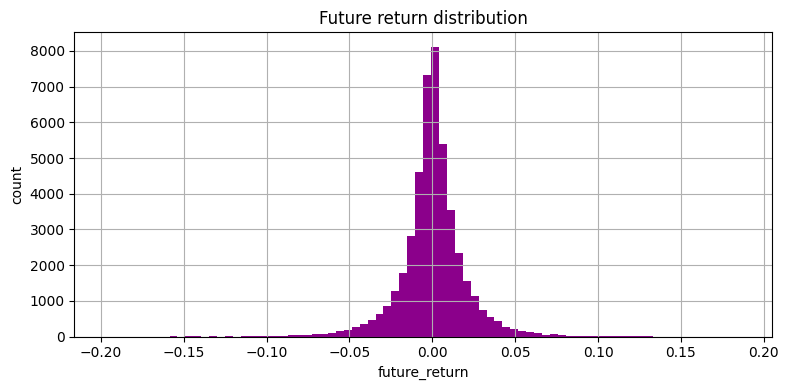

In [31]:
class_counts = labeled_df["target"].value_counts().sort_index()
class_ratio = (class_counts / len(labeled_df)).round(4)

class_report = (
    pd.DataFrame(
        {
            "target": class_counts.index.astype(int),
            "count": class_counts.values.astype(int),
            "ratio": class_ratio.values,
        }
    )
    .reset_index(drop=True)
)

styler.style_me(class_report, title="Class distribution")

plt.figure(figsize=(8, 4))
labeled_df["future_return"].hist(bins=80, color='darkmagenta')
plt.title("Future return distribution")
plt.xlabel("future_return")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### After thoughts:

Rozkład klas po etykietowaniu jest umiarkowanie niezbalansowany:
- `target=0 (sell)`: **11 808** (**25.53%**)
- `target=1 (hold)`: **21 743** (**47.01%**)
- `target=2 (buy)`: **12 701** (**27.46%**)

Najliczniejsza jest klasa `hold`, co jest zgodne z intuicją dla danych godzinowych: większość ruchów w krótkim horyzoncie pozostaje w strefie neutralnej ±0.75%.

Histogram `future_return` jest silnie skupiony wokół zera, z wyraźnymi ogonami po obu stronach.  
To oznacza, że:
1. dominują małe zmiany ceny (szum krótkoterminowy),
2. większe ruchy (dodatnie i ujemne) występują rzadziej, ale są obecne.

W praktyce modelowej:
- rozkład uzasadnia użycie klasy `hold` jako strefy neutralnej,
- umiarkowana nierównowaga klas sugeruje użycie wag klas w treningu (`CrossEntropyLoss(weight=...)`), aby model nie faworyzował klasy `hold`.


### 4. Data saving

In [32]:
os.makedirs(CLEAN_PATH, exist_ok=True)
os.makedirs(LABELED_PATH, exist_ok=True)

CLEAN_FILE = CLEAN_PATH + 'eth_clean.csv'
LABELED_FILE = LABELED_PATH + 'eth_labeled.csv'

clean_df.reset_index().to_csv(CLEAN_FILE, index=False)
labeled_df.reset_index().to_csv(LABELED_FILE, index=False)

styler.show_line(CLEAN_FILE, title='Saved:')
styler.show_line(LABELED_FILE, title='Saved:')


## 02 - Chronological split and target EDA


In [33]:
if 'timestamp' not in labeled_df.columns and labeled_df.index.name == 'timestamp':
    labeled_df = labeled_df.reset_index()

labeled_df = labeled_df.sort_values('timestamp').reset_index(drop=True)


### 1. Chronological split train/val/test

In [ ]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

n = len(labeled_df)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_df = labeled_df.iloc[:train_end].copy()
val_df = labeled_df.iloc[train_end:val_end].copy()
test_df = labeled_df.iloc[val_end:].copy()

split_size_report = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'ratio_real': [len(train_df)/n, len(val_df)/n, len(test_df)/n],
    'start': [train_df['timestamp'].min(), val_df['timestamp'].min(), test_df['timestamp'].min()],
    'end': [train_df['timestamp'].max(), val_df['timestamp'].max(), test_df['timestamp'].max()],
})
styler.style_me(split_size_report, title='Split sizes and time ranges')

,split,rows,ratio_real,start,end
0,train,32376,0.699991,2021-01-01 00:00:00+00:00,2024-09-11 13:00:00+00:00
1,val,6937,0.149983,2024-09-11 14:00:00+00:00,2025-06-27 14:00:00+00:00
2,test,6939,0.150026,2025-06-27 15:00:00+00:00,2026-04-12 17:00:00+00:00


### 2. Anti-leakage control (time)

In [ ]:
split_checks = pd.DataFrame({
    'check': [
        'train_end < val_start',
        'val_end < test_start',
        'train timestamps unique',
        'val timestamps unique',
        'test timestamps unique',
    ],
    'pass': [
        bool(train_df['timestamp'].max() < val_df['timestamp'].min()),
        bool(val_df['timestamp'].max() < test_df['timestamp'].min()),
        bool(train_df['timestamp'].is_unique),
        bool(val_df['timestamp'].is_unique),
        bool(test_df['timestamp'].is_unique),
    ]
})
styler.style_me(split_checks, title='Leakage checks (time order)')

,check,pass
0,train_end < val_start,True
1,val_end < test_start,True
2,train timestamps unique,True
3,val timestamps unique,True
4,test timestamps unique,True


### 3. Target EDA: per split

,split,target,count,ratio
0,train,0,8166,0.252200
1,train,1,15349,0.474100
2,train,2,8861,0.273700
3,val,0,1884,0.271600
4,val,1,3042,0.438500
5,val,2,2011,0.289900
6,test,0,1758,0.253400
7,test,1,3352,0.483100
8,test,2,1829,0.263600


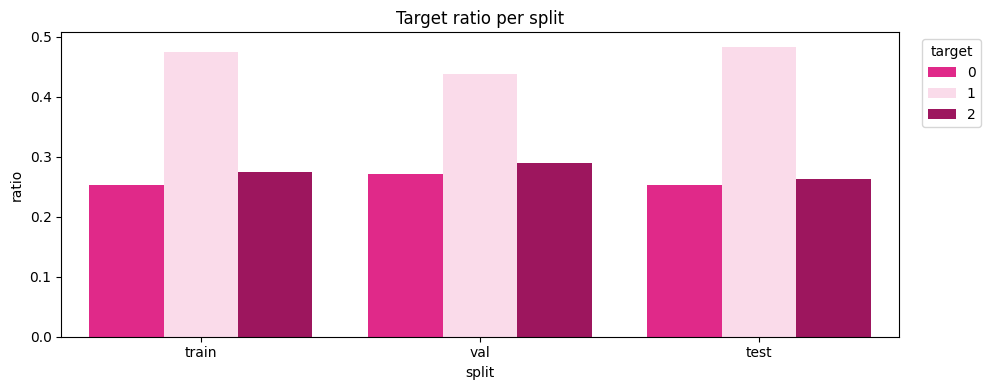

In [36]:
def class_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df['target'].value_counts().sort_index()
    ratios = (counts / len(df)).round(4)
    out = pd.DataFrame({
        'split': split_name,
        'target': counts.index,
        'count': counts.values,
        'ratio': ratios.values,
    })
    return out

per_split_report = pd.concat(
    [
        class_distribution(train_df, 'train'),
        class_distribution(val_df, 'val'),
        class_distribution(test_df, 'test'),
    ],
    ignore_index=True,
)
styler.style_me(per_split_report, title='Class distribution per split')

palette = {
    0: '#ff0a8a',  
    1: '#ffd6ea',  
    2: '#b3005f',  
}

plt.figure(figsize=(10, 4))
sns.barplot(data=per_split_report, x='split', y='ratio', hue='target', palette=palette)
plt.title('Target ratio per split')
plt.xlabel('split')
plt.ylabel('ratio')
plt.legend(title='target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Split Timeline Visualization

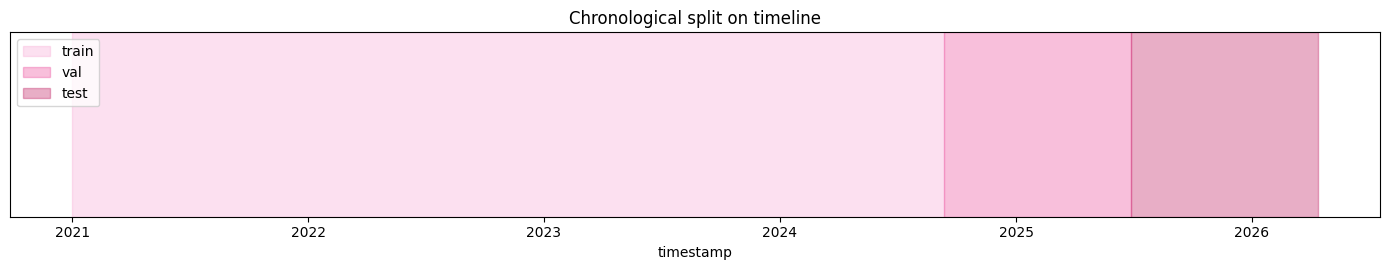

In [37]:
plt.figure(figsize=(14, 2.8))
plt.axvspan(train_df['timestamp'].min(), train_df['timestamp'].max(), alpha=0.35, color='#f9a8d4', label='train')
plt.axvspan(val_df['timestamp'].min(), val_df['timestamp'].max(), alpha=0.35, color='#ec4899', label='val')
plt.axvspan(test_df['timestamp'].min(), test_df['timestamp'].max(), alpha=0.35, color='#be185d', label='test')
plt.yticks([])
plt.xlabel('timestamp')
plt.title('Chronological split on timeline')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 5. Data saving

In [38]:
TRAIN_OUT = LABELED_PATH + 'train_labeled.csv'
VAL_OUT = LABELED_PATH + 'val_labeled.csv'
TEST_OUT = LABELED_PATH + 'test_labeled.csv'
SPLIT_SUMMARY_OUT = LABELED_PATH + 'split_summary.csv'
CLASS_REPORT_OUT = LABELED_PATH + 'class_distribution_per_split.csv'

train_df.to_csv(TRAIN_OUT, index=False)
val_df.to_csv(VAL_OUT, index=False)
test_df.to_csv(TEST_OUT, index=False)

split_size_report.to_csv(SPLIT_SUMMARY_OUT, index=False)
per_split_report.to_csv(CLASS_REPORT_OUT, index=False)

styler.show_line(TRAIN_OUT, title='Saved train split')
styler.show_line(VAL_OUT, title='Saved val split')
styler.show_line(TEST_OUT, title='Saved test split')
styler.show_line(SPLIT_SUMMARY_OUT, title='Saved split summary')
styler.show_line(CLASS_REPORT_OUT, title='Saved class distribution report')


In [39]:
train_split_df = train_df.copy()
val_split_df = val_df.copy()
test_split_df = test_df.copy()

## 03 - Feature engineering


### 1. Timestamp checks

In [40]:
for name, df in [('labeled', labeled_df), ('train', train_split_df), ('val', val_split_df), ('test', test_split_df)]:
    assert 'timestamp' in df.columns, f'{name}: missing timestamp'
    assert isinstance(df['timestamp'].dtype, pd.DatetimeTZDtype), f'{name}: timestamp is not tz-aware datetime'
    assert df['timestamp'].notna().all(), f'{name}: timestamp contains NaT'

labeled_df = labeled_df.sort_values('timestamp').reset_index(drop=True)

split_check = pd.DataFrame({
    'dataset': ['labeled', 'train', 'val', 'test'],
    'rows': [len(labeled_df), len(train_split_df), len(val_split_df), len(test_split_df)],
    'min_ts': [labeled_df['timestamp'].min(), train_split_df['timestamp'].min(), val_split_df['timestamp'].min(), test_split_df['timestamp'].min()],
    'max_ts': [labeled_df['timestamp'].max(), train_split_df['timestamp'].max(), val_split_df['timestamp'].max(), test_split_df['timestamp'].max()],
})
styler.style_me(split_check, title='Input split summary')

,dataset,rows,min_ts,max_ts
0,labeled,46252,2021-01-01 00:00:00+00:00,2026-04-12 17:00:00+00:00
1,train,32376,2021-01-01 00:00:00+00:00,2024-09-11 13:00:00+00:00
2,val,6937,2024-09-11 14:00:00+00:00,2025-06-27 14:00:00+00:00
3,test,6939,2025-06-27 15:00:00+00:00,2026-04-12 17:00:00+00:00


### 2. Feature engineering function definitions

| Nazwa cechy / grupa | Z czego powstaje (jak liczona) | Co wnosi do modelu |
|---|---|---|
| `return_1`, `return_2`, `return_3`, `return_6`, `return_12`, `return_24` | `close.pct_change(period)` | Informacja o kierunku i sile zmiany ceny w różnych horyzontach czasowych. |
| `log_return_1`, `log_return_6`, `log_return_24` | `np.log(close).diff(period)` | Bardziej stabilna numerycznie wersja zwrotu, przydatna przy analizie zmienności. |
| `close_open_pct` | `(close - open) / open` | Kierunek i siła świecy (czy godzina zakończyła się wzrostem czy spadkiem). |
| `high_low_pct` | `(high - low) / close` | Szerokość świecy, czyli intrahour zmienność. |
| `upper_shadow` | `(high - max(open, close)) / close` | Wielkość górnego knota, sygnał odrzucenia wyższych cen. |
| `lower_shadow` | `(min(open, close) - low) / close` | Wielkość dolnego knota, sygnał odrzucenia niższych cen. |
| `body_size` | `abs(close - open) / close` | Siła korpusu świecy, proxy impetu ruchu w godzinie. |
| `rolling_close_mean_*` | `close.rolling(window).mean()` | Lokalny poziom trendu ceny w oknach czasowych. |
| `rolling_return_std_*` | `return_1.rolling(window).std()` | Lokalna zmienność krótkoterminowa. |
| `rolling_close_min_*`, `rolling_close_max_*` | `close.rolling(window).min()/max()` | Lokalny zakres cen, poziomy skrajne. |
| `rolling_return_skew_*` | `return_1.rolling(window).skew()` | Asymetria rozkładu zwrotów (przewaga dodatnich/ujemnych ogonów). |
| `rolling_return_kurt_*` | `return_1.rolling(window).kurt()` | „Grubość ogonów” rozkładu zwrotów (ryzyko skoków). |
| `roc_*` | `close.pct_change(period)` | Tempo zmian ceny (Rate of Change) w danym horyzoncie. |
| `momentum_*` | `close - close.shift(period)` | Surowa różnica ceny, sygnał impetu trendu. |
| `sma_*` | `close.rolling(period).mean()` | Wygładzony trend krótkoterminowy/średnioterminowy. |
| `ema_*` | `close.ewm(span=period).mean()` | Średnia ważona, szybciej reaguje na nowe dane niż SMA. |
| `dist_sma_*` | `(close - sma_*) / close` | Odchylenie ceny od SMA (czy cena jest „nad” lub „pod” trendem). |
| `dist_ema_*` | `(close - ema_*) / close` | Odchylenie ceny od EMA (szybszy sygnał niż dist_sma). |
| `rsi_14` | RSI z 14 okresów (średnie wzrosty/spadki) | Siła ruchu i potencjalne stany wykupienia/wyprzedania. |
| `macd`, `macd_signal`, `macd_hist` | EMA(12), EMA(26), EMA sygnału(9) | Informacja o zmianie dynamiki trendu i przecięciach momentum. |
| `atr_14` | True Range + średnia z 14 okresów | Miara zmienności niezależna od kierunku ruchu. |
| `bb_width` | Szerokość Bollinger Bands względem średniej | Stopień kompresji/rozszerzenia zmienności. |
| `bb_position` | Pozycja ceny względem Bollinger Bands | Gdzie cena leży w kanale zmienności (góra/środek/dół). |
| `volume_return` | `volume.pct_change(1)` | Nagłe zmiany aktywności wolumenowej. |
| `volume_mean_24` | `volume.rolling(24).mean()` | Bazowy poziom wolumenu dobowego. |
| `volume_std_24` | `volume.rolling(24).std()` | Zmienność wolumenu. |
| `volume_zscore_24` | `(volume - volume_mean_24) / volume_std_24` | Anomalie wolumenu względem lokalnej normy. |
| `hour_sin`, `hour_cos` | Sin/cos z godziny doby | Cykliczność dobowa bez sztucznych skoków między 23 i 0. |
| `dow_sin`, `dow_cos` | Sin/cos z dnia tygodnia | Cykliczność tygodniowa handlu. |
| `is_weekend` | `dayofweek >= 5` | Informacja o weekendzie (inna płynność/charakter rynku). |
| `return_1_lag_*`, `return_6_lag_*`, `rsi_14_lag_*`, `macd_hist_lag_*`, `volume_zscore_24_lag_*` | `feature.shift(lag)` dla lagów 1/2/3 | Krótkoterminowa pamięć sygnału i opóźnione zależności czasowe. |


- RSI = Relative Strength Index
- MACD = Moving Average Convergence Divergence
-  ATR = Average True Range

In [ ]:
# RSI: mierzy tempo i siłę ruchu ceny; w krypto pomaga odróżnić stany wykupienia/wyprzedania.
def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


# MACD: sygnał trendu/momentum
def _macd(series: pd.Series) -> tuple[pd.Series, pd.Series, pd.Series]:
    ema_fast = series.ewm(span=12, adjust=False).mean()
    ema_slow = series.ewm(span=26, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal = macd.ewm(span=9, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist


# ATR: miara zmienności świec (średni True Range), istotna przy nagłych skokach zmienności na rynku krypto.
def _atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    high_low = df['high'] - df['low']
    high_close = (df['high'] - df['close'].shift(1)).abs()
    low_close = (df['low'] - df['close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return tr.rolling(period).mean()


# Zwroty i log-zwroty: opisują krótkie i średnie ruchy ceny ETH w horyzontach 1h-24h.
def add_return_features(work: pd.DataFrame) -> pd.DataFrame:
    for period in [1, 2, 3, 6, 12, 24]:
        work[f'return_{period}'] = work['close'].pct_change(period)

    work['log_return_1'] = np.log(work['close']).diff(1)
    work['log_return_6'] = np.log(work['close']).diff(6)
    work['log_return_24'] = np.log(work['close']).diff(24)
    return work


# Geometria świecy: pokazuje charakter pojedynczej godziny (korpus, cienie, amplituda ruchu).
def add_candle_features(work: pd.DataFrame) -> pd.DataFrame:
    work['close_open_pct'] = (work['close'] - work['open']) / work['open']
    work['high_low_pct'] = (work['high'] - work['low']) / work['close']
    work['upper_shadow'] = (work['high'] - work[['open', 'close']].max(axis=1)) / work['close']
    work['lower_shadow'] = (work[['open', 'close']].min(axis=1) - work['low']) / work['close']
    work['body_size'] = (work['close'] - work['open']).abs() / work['close']
    return work


# Statystyki kroczące: kontekst lokalnej struktury rynku (trend, rozrzut, asymetria, "ogonowość" zwrotów).
def add_rolling_features(work: pd.DataFrame) -> pd.DataFrame:
    for window in [6, 12, 24, 48]:
        work[f'rolling_close_mean_{window}'] = work['close'].rolling(window).mean()
        work[f'rolling_return_std_{window}'] = work['return_1'].rolling(window).std()
        work[f'rolling_close_min_{window}'] = work['close'].rolling(window).min()
        work[f'rolling_close_max_{window}'] = work['close'].rolling(window).max()
        work[f'rolling_return_skew_{window}'] = work['return_1'].rolling(window).skew()
        work[f'rolling_return_kurt_{window}'] = work['return_1'].rolling(window).kurt()
    return work


# Cechy trendowe: momentum, ROC, SMA/EMA i odległość ceny od średnich.
def add_trend_features(work: pd.DataFrame) -> pd.DataFrame:
    for period in [6, 12, 24]:
        work[f'roc_{period}'] = work['close'].pct_change(period)
        work[f'momentum_{period}'] = work['close'] - work['close'].shift(period)
        work[f'sma_{period}'] = work['close'].rolling(period).mean()
        work[f'ema_{period}'] = work['close'].ewm(span=period, adjust=False).mean()
        work[f'dist_sma_{period}'] = (work['close'] - work[f'sma_{period}']) / work['close']
        work[f'dist_ema_{period}'] = (work['close'] - work[f'ema_{period}']) / work['close']
    return work


# Wskaźniki techniczne: RSI/MACD/ATR oraz Bollinger Bands jako syntetyczny opis trendu i zmienności.
def add_indicator_features(work: pd.DataFrame) -> pd.DataFrame:
    work['rsi_14'] = _rsi(work['close'], period=14)
    macd, macd_signal, macd_hist = _macd(work['close'])
    work['macd'] = macd
    work['macd_signal'] = macd_signal
    work['macd_hist'] = macd_hist
    work['atr_14'] = _atr(work, period=14)

    rolling_mean_20 = work['close'].rolling(20).mean()
    rolling_std_20 = work['close'].rolling(20).std()
    bb_upper = rolling_mean_20 + 2 * rolling_std_20
    bb_lower = rolling_mean_20 - 2 * rolling_std_20
    work['bb_width'] = (bb_upper - bb_lower) / rolling_mean_20
    work['bb_position'] = (work['close'] - bb_lower) / (bb_upper - bb_lower)
    return work


# Wolumen: sygnały aktywności rynku i odchylenia wolumenu od lokalnej normy (z-score).
def add_volume_features(work: pd.DataFrame) -> pd.DataFrame:
    work['volume_return'] = work['volume'].pct_change(1)
    work['volume_mean_24'] = work['volume'].rolling(24).mean()
    work['volume_std_24'] = work['volume'].rolling(24).std()
    work['volume_zscore_24'] = (work['volume'] - work['volume_mean_24']) / work['volume_std_24']
    return work


# Kalendarz: cykliczność godzin i dni tygodnia, typowa dla płynności i zachowania traderów na krypto.
def add_calendar_features(work: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(work.index, pd.DatetimeIndex):
        raise ValueError('DataFrame index must be DatetimeIndex for calendar features.')

    hour = work.index.hour
    day = work.index.dayofweek
    work['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    work['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    work['dow_sin'] = np.sin(2 * np.pi * day / 7)
    work['dow_cos'] = np.cos(2 * np.pi * day / 7)
    work['is_weekend'] = (day >= 5).astype(int)
    return work


# Lagi: pamięć krótkoterminowa sygnału (model dostaje historię 1-3h wybranych cech).
def add_lag_features(work: pd.DataFrame) -> pd.DataFrame:
    lag_features = ['return_1', 'return_6', 'rsi_14', 'macd_hist', 'volume_zscore_24']
    for col in lag_features:
        for lag in [1, 2, 3]:
            work[f'{col}_lag_{lag}'] = work[col].shift(lag)
    return work


def create_features(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()

    work = add_return_features(work)
    work = add_candle_features(work)
    work = add_rolling_features(work)
    work = add_trend_features(work)
    work = add_indicator_features(work)
    work = add_volume_features(work)
    work = add_calendar_features(work)
    work = add_lag_features(work)

    return work



### 3. Feature construction and leakage control
- z danych bazowych powstaje macierz cech do modelowania.

In [42]:
work_df = labeled_df.sort_values('timestamp').set_index('timestamp')
features_full = create_features(work_df)

feature_cols = [c for c in features_full.columns if c not in ['target', 'future_return']]

styler.show_line(len(feature_cols), title='Number of candidate feature columns')
styler.style_me(pd.DataFrame({'feature_columns_sample': feature_cols}), title='Feature sample (all of them)')


,feature_columns_sample
0,open
1,high
2,low
3,close
4,volume
5,quote_asset_volume
6,number_of_trades
7,taker_buy_base_asset_volume
8,taker_buy_quote_asset_volume
9,return_1


### 4. NaN/Inf report after feature engineering

In [43]:
inf_report = (
    pd.DataFrame(
        {
            'column': features_full.columns,
            'pos_inf_count': np.isinf(features_full.to_numpy(dtype=np.float64)).sum(axis=0),
            'neg_inf_count': np.isneginf(features_full.to_numpy(dtype=np.float64)).sum(axis=0),
        }
    )
)
inf_report['inf_total'] = inf_report['pos_inf_count'] + inf_report['neg_inf_count']
inf_report = inf_report[inf_report['inf_total'] > 0].sort_values('inf_total', ascending=False)

if len(inf_report) > 0:
    styler.style_me(inf_report.head(30), title='Columns with +/-inf after feature engineering')

features_full = features_full.replace([np.inf, -np.inf], np.nan)

nan_report = features_full.isna().sum().sort_values(ascending=False)
nan_report = nan_report[nan_report > 0].to_frame('nan_count').reset_index().rename(columns={'index': 'column'})

styler.style_me(nan_report.head(30), title='Top NaN counts after feature engineering')

rows_before_dropna = len(features_full)
features_clean = features_full.dropna().copy()
rows_after_dropna = len(features_clean)
rows_removed = rows_before_dropna - rows_after_dropna

dropna_report = pd.DataFrame(
    {
        'rows_before_dropna': [rows_before_dropna],
        'rows_after_dropna': [rows_after_dropna],
        'rows_removed': [rows_removed],
        'removed_pct': [round(rows_removed / rows_before_dropna * 100, 4)],
    }
)
styler.style_me(dropna_report, title='Dropna report')


,column,pos_inf_count,neg_inf_count,inf_total
74,volume_return,2,0,2


,column,nan_count
0,rolling_return_kurt_48,48
1,rolling_return_skew_48,48
2,rolling_return_std_48,48
3,rolling_close_mean_48,47
4,rolling_close_max_48,47
5,rolling_close_min_48,47
6,volume_zscore_24_lag_3,26
7,volume_zscore_24_lag_2,25
8,momentum_24,24
9,rolling_return_kurt_24,24


,rows_before_dropna,rows_after_dropna,rows_removed,removed_pct
0,46252,46202,50,0.108100


### Cleaning data thoughts:

Po utworzeniu cech pojawiły się wartości `NaN` i pojedyncze `+inf`, co jest naturalnym efektem operacji sekwencyjnych (rolling, lagi, zmiany procentowe).

- Wykryte `+inf` wystąpiły w kolumnie `volume_return` (2 przypadki).  
  Źródło: `pct_change` przy zerowym wolumenie w poprzedniej obserwacji (dzielenie przez 0).  
  Dlatego zastosowano bezpieczne czyszczenie: `±inf -> NaN`.

- Największe liczby `NaN` występują w cechach opartych o długie okna (`window=48`) i statystyki rolling (`std/skew/kurt`), np. `rolling_return_kurt_48`, `rolling_return_skew_48`, `rolling_return_std_48`.  
  To oczekiwane, ponieważ takie cechy wymagają pełnego „rozbiegu” okna i nie mogą być policzone dla pierwszych obserwacji.

- `NaN` pojawiają się także w cechach lagowanych (np. `*_lag_1/2/3`) oraz w cechach opartych o horyzont 24h (`return_24`, `roc_24`, `momentum_24`, `sma_24`), ponieważ każda z nich potrzebuje odpowiedniej liczby poprzednich punktów.

Po zamianie `inf` na `NaN` i zastosowaniu `dropna`:
- `rows_before_dropna = 46252`
- `rows_after_dropna = 46202`
- `rows_removed = 50` (`~0.1081%`)

Usunięto bardzo mały odsetek rekordów, więc wpływ na reprezentatywność danych jest minimalny, a jakość wejścia do modelu znacząco lepsza (brak wartości niefinitywnych i niekompletnych).

### 5. Assignment to existing splits from part 02

In [44]:
train_ts = set(train_split_df['timestamp'])
val_ts = set(val_split_df['timestamp'])
test_ts = set(test_split_df['timestamp'])

features_reset = features_clean.reset_index()

train_features = features_reset[features_reset['timestamp'].isin(train_ts)]
val_features = features_reset[features_reset['timestamp'].isin(val_ts)]
test_features = features_reset[features_reset['timestamp'].isin(test_ts)]

split_overlap_report = pd.DataFrame({
    'check': ['train_val_overlap', 'train_test_overlap', 'val_test_overlap'],
    'value': [
        len(set(train_features['timestamp']).intersection(set(val_features['timestamp']))),
        len(set(train_features['timestamp']).intersection(set(test_features['timestamp']))),
        len(set(val_features['timestamp']).intersection(set(test_features['timestamp']))),
    ]
})
styler.style_me(split_overlap_report, title='Overlap check after feature assignment')

features_split_report = pd.DataFrame({
    'split': ['train_features', 'val_features', 'test_features'],
    'rows': [len(train_features), len(val_features), len(test_features)],
    'min_ts': [train_features['timestamp'].min(), val_features['timestamp'].min(), test_features['timestamp'].min()],
    'max_ts': [train_features['timestamp'].max(), val_features['timestamp'].max(), test_features['timestamp'].max()],
})
styler.style_me(features_split_report, title='Feature split summary')


,check,value
0,train_val_overlap,0
1,train_test_overlap,0
2,val_test_overlap,0


,split,rows,min_ts,max_ts
0,train_features,32326,2021-01-03 00:00:00+00:00,2024-09-11 13:00:00+00:00
1,val_features,6937,2024-09-11 14:00:00+00:00,2025-06-27 14:00:00+00:00
2,test_features,6939,2025-06-27 15:00:00+00:00,2026-04-12 17:00:00+00:00


### 6. Quick feature report

In [45]:
model_feature_cols = [c for c in train_features.columns if c not in ['timestamp', 'target', 'future_return']]

summary_report = pd.DataFrame({
    'metric': ['all_feature_columns', 'model_feature_columns', 'train_rows', 'val_rows', 'test_rows'],
    'value': [
        len(feature_cols),
        len(model_feature_cols),
        len(train_features),
        len(val_features),
        len(test_features),
    ],
})
styler.style_me(summary_report, title='Feature engineering summary')

styler.style_me(train_features[model_feature_cols].describe().T.head(20), title='Train feature stats (sample)')


,metric,value
0,all_feature_columns,96
1,model_feature_columns,96
2,train_rows,32326
3,val_rows,6937
4,test_rows,6939


,count,mean,std,min,25%,50%,75%,max
open,32326.000000,2353.336937,877.026666,772.440000,1651.937500,2080.985000,3060.637500,4846.940000
high,32326.000000,2366.286804,881.873972,778.440000,1658.772500,2090.635000,3078.037500,4868.000000
low,32326.000000,2339.426145,871.633946,768.710000,1645.770000,2070.165000,3040.997500,4833.190000
close,32326.000000,2353.383743,876.983093,772.370000,1651.957500,2081.025000,3060.635000,4846.710000
volume,32326.000000,25142.775613,28012.053162,0.000000,9314.362950,16509.822400,30480.678343,493227.882820
quote_asset_volume,32326.000000,55201283.119651,59016320.137777,0.000000,20818157.588868,38615335.233544,68016878.416895,1170475765.355900
number_of_trades,32326.000000,41249.951680,36384.433980,0.000000,19755.000000,31086.000000,50009.750000,1067023.000000
taker_buy_base_asset_volume,32326.000000,12523.885781,13938.937043,0.000000,4607.357125,8250.416050,15177.926525,238996.465800
taker_buy_quote_asset_volume,32326.000000,27493349.584836,29266344.083677,0.000000,10303611.268760,19292910.179072,33950951.761822,563990279.637153
return_1,32326.000000,0.000072,0.008663,-0.130794,-0.003073,0.000067,0.003298,0.092128


### 7. Saving artifacts

In [46]:
FEATURES_FULL_OUT = PROCESSED_PATH + 'features_full.csv'
TRAIN_FEATURES_OUT = PROCESSED_PATH + 'train_features.csv'
VAL_FEATURES_OUT = PROCESSED_PATH + 'val_features.csv'
TEST_FEATURES_OUT = PROCESSED_PATH + 'test_features.csv'
FEATURE_LIST_OUT = PROCESSED_PATH + 'feature_columns.csv'

features_reset.to_csv(FEATURES_FULL_OUT, index=False)
train_features.to_csv(TRAIN_FEATURES_OUT, index=False)
val_features.to_csv(VAL_FEATURES_OUT, index=False)
test_features.to_csv(TEST_FEATURES_OUT, index=False)

pd.DataFrame({'feature_column': model_feature_cols}).to_csv(FEATURE_LIST_OUT, index=False)

styler.show_line(FEATURES_FULL_OUT, title='Saved full features')
styler.show_line(TRAIN_FEATURES_OUT, title='Saved train features')
styler.show_line(VAL_FEATURES_OUT, title='Saved val features')
styler.show_line(TEST_FEATURES_OUT, title='Saved test features')
styler.show_line(FEATURE_LIST_OUT, title='Saved feature list')


In [ ]:
# przygotowanie finalnych ramek do modelowania
train_df, val_df, test_df = [
    df.sort_values('timestamp').reset_index(drop=True)
    for df in (train_features, val_features, test_features)
]

train_val_df = pd.concat([train_df, val_df], axis=0).sort_values('timestamp').reset_index(drop=True)
meta_cols = ['timestamp', 'target', 'future_return']
feature_cols = [c for c in train_val_df.columns if c not in meta_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_val_df[c])]

## 04 - Train/Val EDA and multicollinearity


### 1. Histograms and pairplot (train+val only)

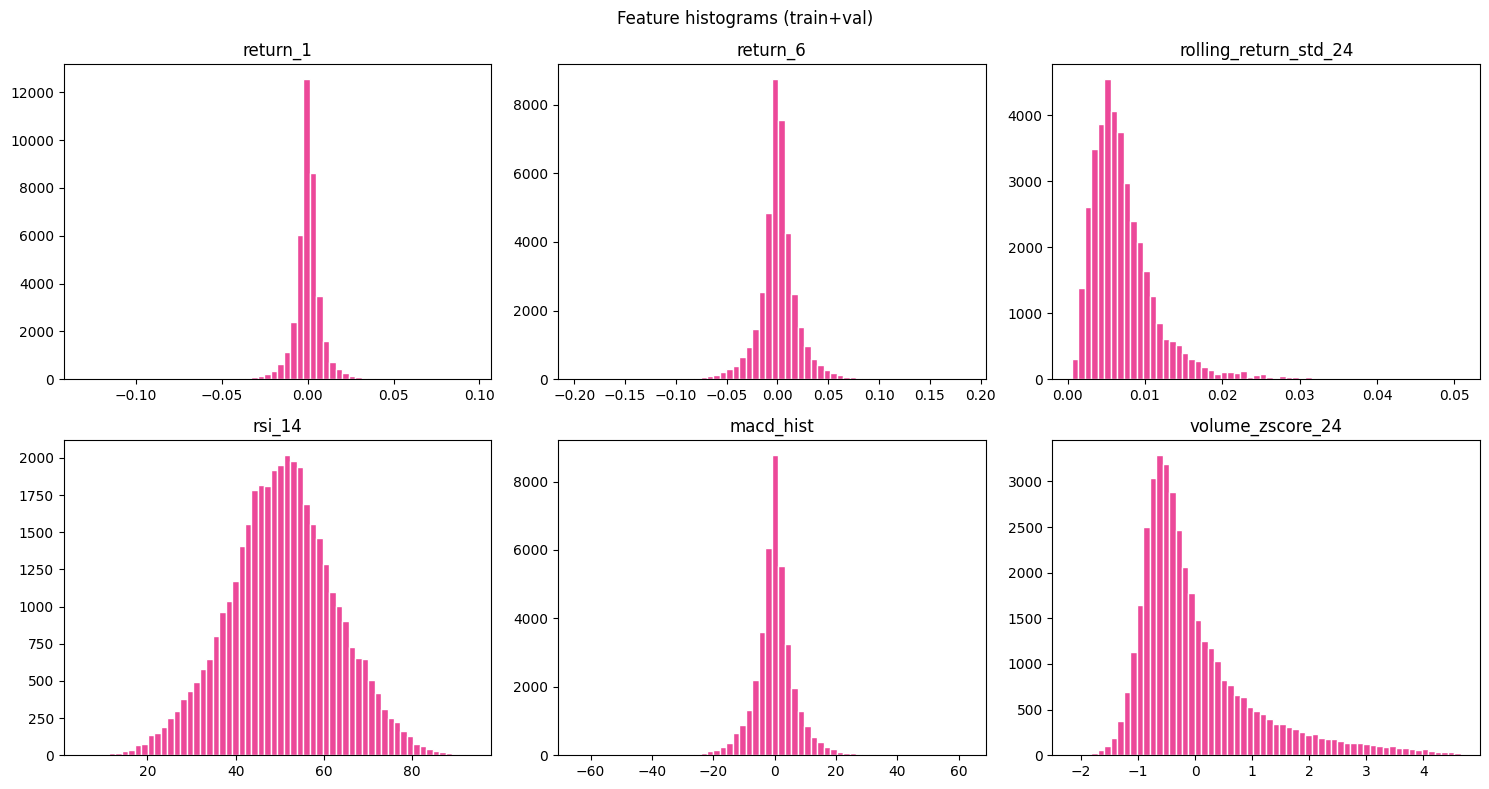

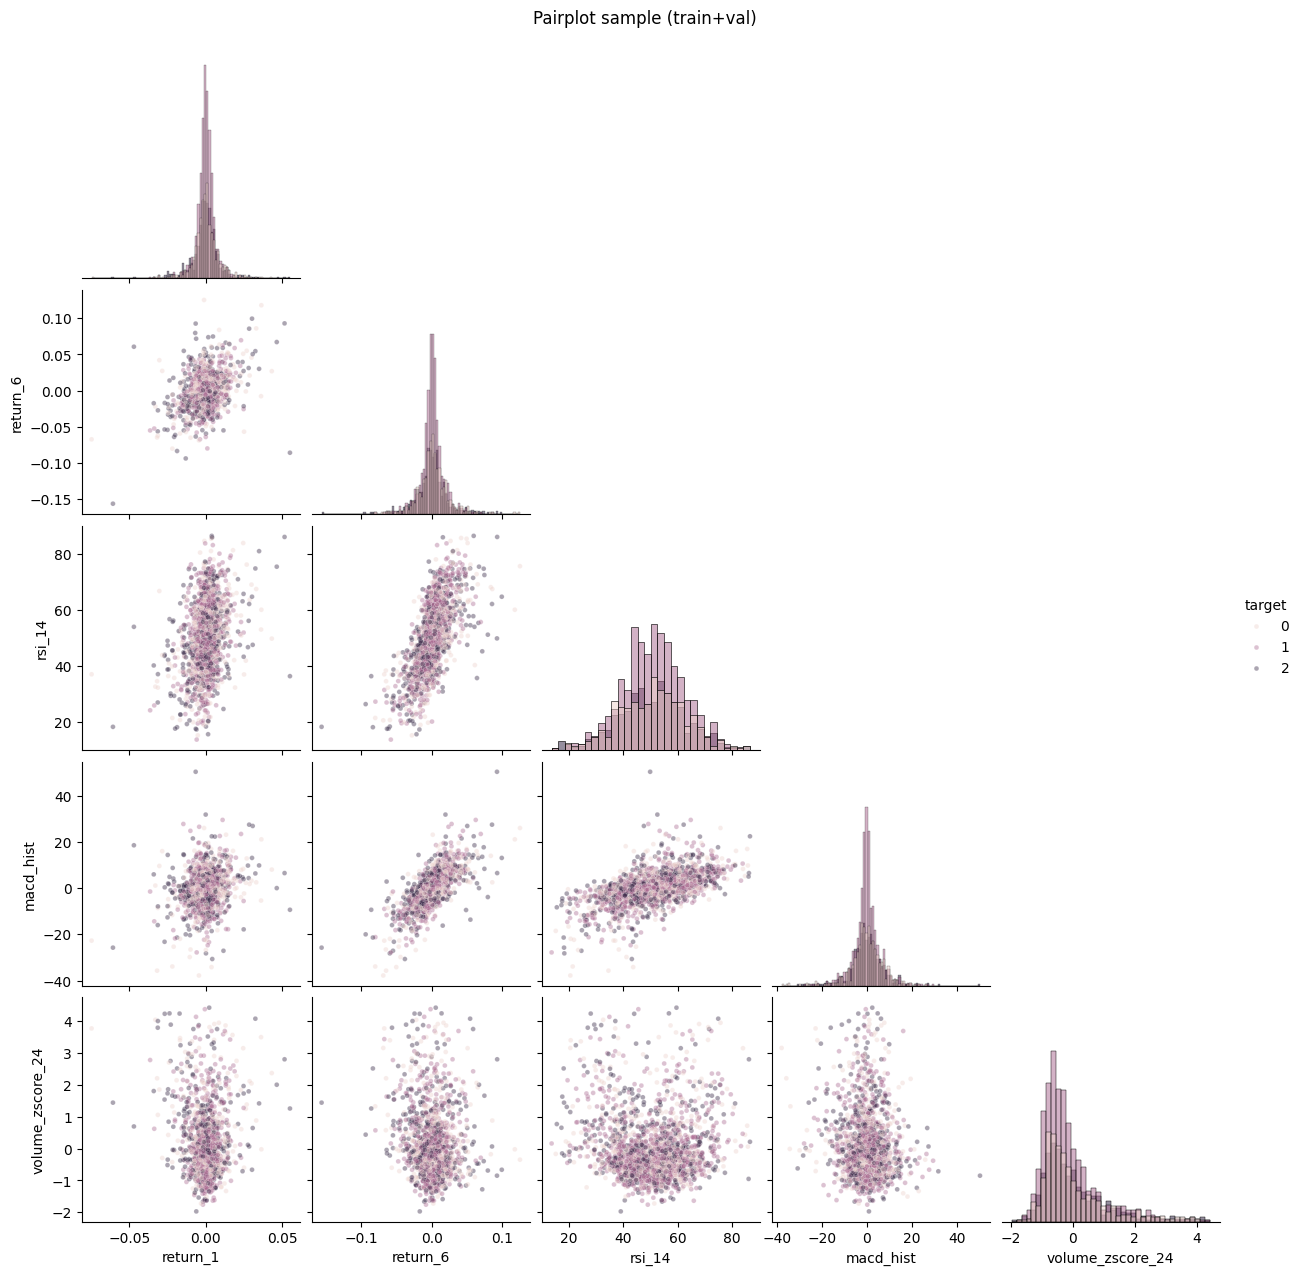

In [48]:
# due to a large number of features (96) only a few histograms are displayed
eda_candidates = [
    'return_1',
    'return_6',
    'rolling_return_std_24',
    'rsi_14',
    'macd_hist',
    'volume_zscore_24',
]
eda_features = [c for c in eda_candidates if c in feature_cols]

if len(eda_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(eda_features):
        axes[i].hist(train_val_df[col], bins=60, color='#ec4899', edgecolor='white')
        axes[i].set_title(col)
    for j in range(len(eda_features), len(axes)):
        axes[j].axis('off')
    plt.suptitle('Feature histograms (train+val)')
    plt.tight_layout()
    plt.show()

pairplot_cols = [c for c in ['return_1', 'return_6', 'rsi_14', 'macd_hist', 'volume_zscore_24', 'target'] if c in train_val_df.columns]
if len(pairplot_cols) >= 3:
    sample_n = min(2000, len(train_val_df))
    pairplot_df = train_val_df[pairplot_cols].sample(sample_n, random_state=42)
    sns.pairplot(pairplot_df, hue='target', diag_kind='hist', corner=True, plot_kws={'alpha': 0.4, 's': 12})
    plt.suptitle('Pairplot sample (train+val)', y=1.02)
    plt.show()


### Wnioski
- Histogramy potwierdzaja, ze cechy rynkowe maja rozklady niesymetryczne i czesto z grubymi ogonami (outliery), co jest typowe dla danych krypto.
- Pairplot dla probki 2000 obserwacji nie pokazuje wyraznej separacji klas po pojedynczych cechach, wiec samy prosty prog na jednej zmiennej raczej nie wystarczy.
- Ten etap sluzy glownie do sanity-checku danych przed filtrami korelacji i VIF.


### 2. Feature covariance and high-correlation filter

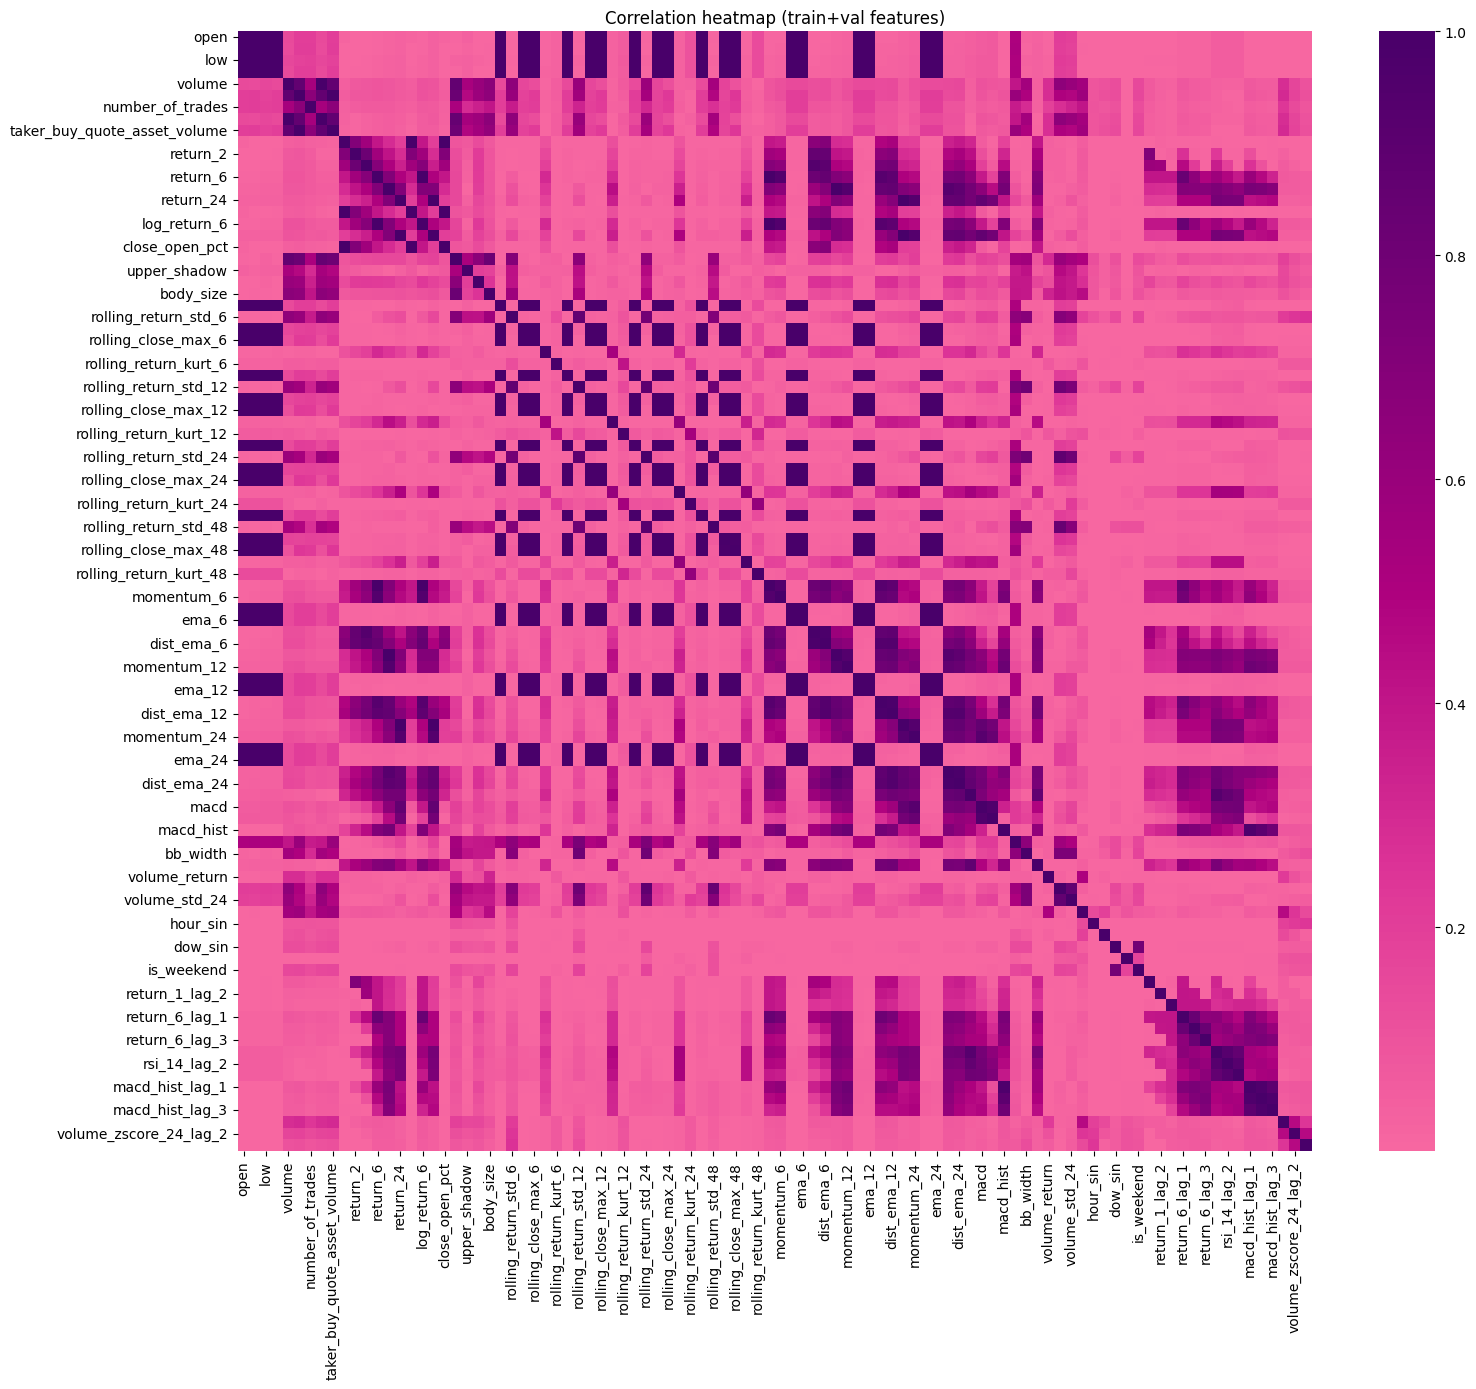

,stage,feature_count
0,initial_features,96
1,after_constant_drop,96
2,after_corr_drop,59


,dropped_constant


,dropped_corr
0,high
1,low
2,close
3,taker_buy_base_asset_volume
4,taker_buy_quote_asset_volume
5,log_return_1
6,log_return_6
7,log_return_24
8,close_open_pct
9,rolling_close_mean_6


In [49]:
def drop_constant_features(df: pd.DataFrame, min_unique: int = 2):
    to_drop = [c for c in df.columns if df[c].nunique(dropna=False) < min_unique]
    return df.drop(columns=to_drop), to_drop


def drop_highly_correlated_features(df: pd.DataFrame, threshold: float = 0.95):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop, corr

X_train_val = train_val_df[feature_cols]
X_train_val = X_train_val.replace([np.inf, -np.inf], np.nan)
X_train_val = X_train_val.dropna()

X_no_const, dropped_constant = drop_constant_features(X_train_val)
X_no_corr, dropped_corr, corr_matrix = drop_highly_correlated_features(X_no_const, threshold=0.95)

EDA_REPORTS_PATH = '../../reports/eda/'
os.makedirs(EDA_REPORTS_PATH, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='RdPu', center=0, ax=ax)
ax.set_title('Correlation heatmap (train+val features)')
fig.tight_layout()
fig.savefig(EDA_REPORTS_PATH + 'corr_heatmap_train_val.png', dpi=300, bbox_inches='tight')
plt.show()

filter_report = pd.DataFrame({
    'stage': ['initial_features', 'after_constant_drop', 'after_corr_drop'],
    'feature_count': [len(X_train_val.columns), len(X_no_const.columns), len(X_no_corr.columns)],
})
styler.style_me(filter_report, title='Feature count after constant/correlation filters')
styler.style_me(pd.DataFrame({'dropped_constant': dropped_constant}), title='Dropped constant features')
styler.style_me(pd.DataFrame({'dropped_corr': dropped_corr}), title='Dropped high-corr features')


#### Wnioski
- Na tym etapie startujemy z 96 cechami numerycznymi i usuwamy redundancje liniowa.
- Nie wykryto cech stalych (`dropped_constant_count = 0`), wiec kazda cecha miala co najmniej 2 wartosci unikalne.
- Filtr korelacji `|corr| > 0.95` odrzucil 37 cech (`dropped_corr_count = 37`).
- Odrzucenia byly uzasadnione: w macierzy widac prawie duplikaty informacyjne, np. `return_6 ~ roc_6`, `return_12 ~ roc_12`, `return_24 ~ roc_24`, `rolling_close_mean_6 ~ sma_6`.


### 3. VIF analysis 
(Variance Inflation Factor) to miara współliniowości cechy z innymi cechami

In [ ]:
def prepare_vif_input(df: pd.DataFrame, sample_n: int | None = 15000) -> pd.DataFrame:
    """Prepare numeric, finite, non-null data used for VIF evaluation."""
    work = (
        df.select_dtypes(include=[np.number])
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if sample_n is not None and len(work) > sample_n:
        work = work.sample(sample_n, random_state=42)

    return work


def compute_vif_table(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute VIF for the provided column subset and sort descending."""
    X = data[cols].values
    vif_values = []

    for i, col in enumerate(cols):
        try:
            v = variance_inflation_factor(X, i)
        except Exception:
            v = np.inf
        vif_values.append(float(v))

    return pd.DataFrame({'feature': cols, 'vif': vif_values}).sort_values('vif', ascending=False)


def reduce_vif_features(
    df: pd.DataFrame,
    vif_threshold: float = 10.0,
    max_iter: int = 100,
    sample_n: int | None = 15000,
):
    """Iteratively drop the highest-VIF feature until threshold is met."""
    data = prepare_vif_input(df, sample_n=sample_n)

    if data.shape[1] < 2:
        return list(data.columns), [], pd.DataFrame(columns=['feature', 'vif'])

    cols = list(data.columns)
    dropped = []

    for _ in range(max_iter):
        vif_df = compute_vif_table(data, cols)

        if vif_df.empty or len(cols) < 2:
            return cols, dropped, vif_df

        max_vif = float(vif_df['vif'].iloc[0])
        if max_vif <= vif_threshold:
            return cols, dropped, vif_df

        drop_col = str(vif_df['feature'].iloc[0])
        cols.remove(drop_col)
        dropped.append(drop_col)

    final_vif = compute_vif_table(data, cols) if len(cols) >= 2 else pd.DataFrame({'feature': cols, 'vif': [np.nan] * len(cols)})
    return cols, dropped, final_vif


kept_after_vif, dropped_vif, vif_table = reduce_vif_features(
    X_no_corr,
    vif_threshold=10.0,
    max_iter=100,
    sample_n=15000,
)

styler.style_me(vif_table.head(30), title='Top VIF values (after iterative reduction)')
styler.style_me(pd.DataFrame({'dropped_vif': dropped_vif}), title='Dropped VIF features')


c:\Users\ankap\OneDrive\Desktop\PROJEKTY\nn\eth-mlp-project\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,vif
1,quote_asset_volume,9.075810
20,bb_width,7.508065
21,bb_position,7.458454
4,return_12,7.407220
8,rolling_return_std_6,7.359050
23,volume_std_24,7.351389
33,return_6_lag_1,6.887974
0,open,6.761543
17,momentum_6,6.290377
19,macd_hist,5.742328


,dropped_vif
0,body_size
1,return_2
2,return_3
3,rsi_14_lag_1
4,rsi_14_lag_2
5,rsi_14
6,dist_sma_12
7,dist_sma_6
8,dist_sma_24
9,rolling_return_std_24


### 4. Feature-target relation (train+val)

,feature,mutual_info
1,quote_asset_volume,0.046206
8,rolling_return_std_6,0.043782
2,number_of_trades,0.041060
23,volume_std_24,0.037399
20,bb_width,0.036469
0,open,0.031818
6,upper_shadow,0.025212
18,macd,0.022126
5,return_24,0.019261
7,lower_shadow,0.017995


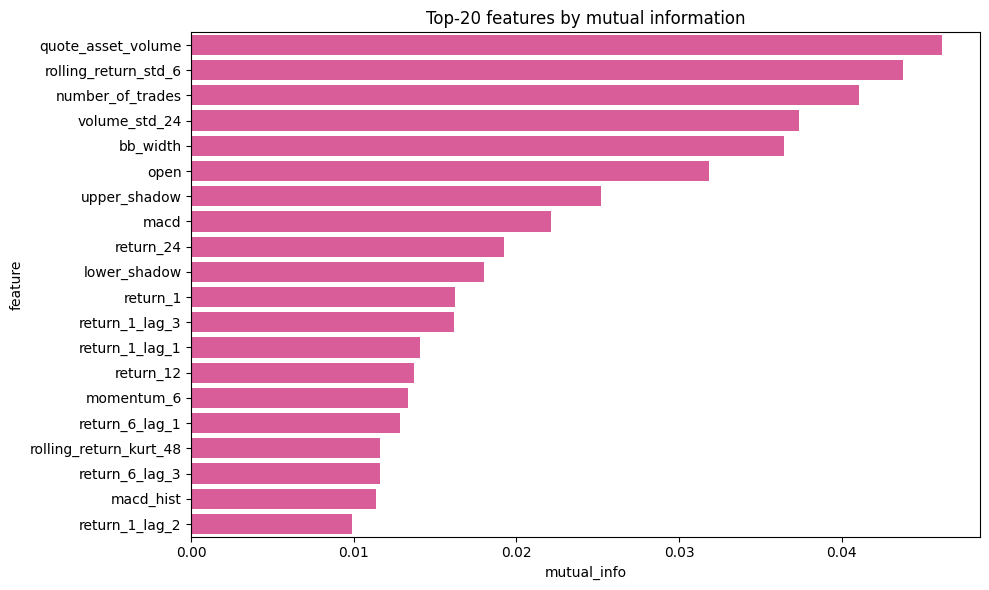

In [ ]:
X_mi = X_no_corr[kept_after_vif]
y_mi = train_val_df.loc[X_mi.index, 'target'].astype(int)

mi_values = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({'feature': X_mi.columns, 'mutual_info': mi_values}).sort_values('mutual_info', ascending=False)

styler.style_me(mi_df.head(30), title='Top features by mutual information (train+val)')

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df.head(20), x='mutual_info', y='feature', color='#ec4899')
plt.title('Top-20 features by mutual information')
plt.tight_layout()
plt.show()

#### Wnioski
- Mutual information pokazuje, ktore cechy niosa najwiecej informacji o targetcie po filtrach wspolliniowosci.
- Najmocniejsze cechy w tym runie: `quote_asset_volume (0.0462)`, `rolling_return_std_6 (0.0438)`, `number_of_trades (0.0411)`, `volume_std_24 (0.0374)`, `bb_width (0.0365)`.
- Wartosci MI sa relatywnie niskie, co jest normalne dla szumnego rynku krypto: sygnal istnieje, ale jest slab y i rozproszony miedzy cechami.


### 5. Final selected feature set & apply to train/val/test

In [ ]:
selected_features = list(kept_after_vif)

final_drop_set = set(dropped_constant) | set(dropped_corr) | set(dropped_vif)
final_drop_list = sorted(final_drop_set)

train_selected = train_df[['timestamp', 'target', 'future_return'] + selected_features]
val_selected = val_df[['timestamp', 'target', 'future_return'] + selected_features]
test_selected = test_df[['timestamp', 'target', 'future_return'] + selected_features]

selection_summary = pd.DataFrame({
    'metric': [
        'initial_feature_count',
        'dropped_constant_count',
        'dropped_corr_count',
        'dropped_vif_count',
        'final_selected_count',
    ],
    'value': [
        len(feature_cols),
        len(dropped_constant),
        len(dropped_corr),
        len(dropped_vif),
        len(selected_features),
    ],
})
styler.style_me(selection_summary, title='Feature selection summary')

,metric,value
0,initial_feature_count,96
1,dropped_constant_count,0
2,dropped_corr_count,37
3,dropped_vif_count,21
4,final_selected_count,38


#### Wnioski
- Finalny zestaw ma 38 cech (`final_selected_count = 38`) z poczatkowych 96.
- Odrzucenia wynikaly z trzech powodow: stale cechy (0), bardzo wysoka korelacja (37) i zbyt wysoki VIF (21).
- Ten sam zestaw cech zostal konsekwentnie zastosowany do `train`, `val` i `test`, co utrzymuje spojnosc pipeline'u.


### 6. Saving artifacts

In [53]:
TRAIN_SELECTED_OUT = PROCESSED_PATH + 'train_selected.csv'
VAL_SELECTED_OUT = PROCESSED_PATH + 'val_selected.csv'
TEST_SELECTED_OUT = PROCESSED_PATH + 'test_selected.csv'
SELECTED_FEATURES_OUT = PROCESSED_PATH + 'selected_feature_columns.csv'
SELECTION_REPORT_OUT = PROCESSED_PATH + 'feature_selection_report.csv'
DROP_LIST_OUT = PROCESSED_PATH + 'dropped_features_report.csv'
MI_REPORT_OUT = PROCESSED_PATH + 'feature_target_mi.csv'
VIF_REPORT_OUT = PROCESSED_PATH + 'vif_table.csv'

train_selected.to_csv(TRAIN_SELECTED_OUT, index=False)
val_selected.to_csv(VAL_SELECTED_OUT, index=False)
test_selected.to_csv(TEST_SELECTED_OUT, index=False)

pd.DataFrame({'feature_column': selected_features}).to_csv(SELECTED_FEATURES_OUT, index=False)
selection_summary.to_csv(SELECTION_REPORT_OUT, index=False)
pd.DataFrame({'dropped_feature': final_drop_list}).to_csv(DROP_LIST_OUT, index=False)
mi_df.to_csv(MI_REPORT_OUT, index=False)
vif_table.to_csv(VIF_REPORT_OUT, index=False)

styler.show_line(TRAIN_SELECTED_OUT, title='Saved train_selected')
styler.show_line(VAL_SELECTED_OUT, title='Saved val_selected')
styler.show_line(TEST_SELECTED_OUT, title='Saved test_selected')
styler.show_line(SELECTED_FEATURES_OUT, title='Saved selected features list')
styler.show_line(SELECTION_REPORT_OUT, title='Saved selection summary')


In [54]:
train_df = train_selected
val_df = val_selected
test_df = test_selected

## 05 - Scaling and DataLoaders


### 1. Building X/y and choosing scaler

In [ ]:
X_train = train_df[selected_features].to_numpy(dtype=np.float32)
X_val = val_df[selected_features].to_numpy(dtype=np.float32)
X_test = test_df[selected_features].to_numpy(dtype=np.float32)

y_train = train_df['target'].to_numpy(dtype=np.int64)
y_val = val_df['target'].to_numpy(dtype=np.int64)
y_test = test_df['target'].to_numpy(dtype=np.int64)

assert np.isfinite(X_train).all(), 'X_train contains NaN/inf'
assert np.isfinite(X_val).all(), 'X_val contains NaN/inf'
assert np.isfinite(X_test).all(), 'X_test contains NaN/inf'


def estimate_outlier_ratio_iqr(X: np.ndarray) -> float:
    q1 = np.percentile(X, 25, axis=0)
    q3 = np.percentile(X, 75, axis=0)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (X < low) | (X > high)
    return float(mask.mean())

outlier_ratio = estimate_outlier_ratio_iqr(X_train)
AUTO_SCALER = 'robust' if outlier_ratio > 0.05 else 'standard'

SCALER_TYPE = AUTO_SCALER  # override manually if needed: 'standard' / 'robust'
if SCALER_TYPE == 'standard':
    scaler = StandardScaler()
elif SCALER_TYPE == 'robust':
    scaler = RobustScaler()
else:
    raise ValueError(f'Unsupported SCALER_TYPE: {SCALER_TYPE}')

styler.style_me(
    pd.DataFrame({
        'metric': ['train_outlier_ratio_iqr', 'auto_scaler_choice', 'final_scaler_choice'],
        'value': [outlier_ratio, AUTO_SCALER, SCALER_TYPE],
    }),
    title='Scaler choice rationale',
)

,metric,value
0,train_outlier_ratio_iqr,0.055183
1,auto_scaler_choice,robust
2,final_scaler_choice,robust


### 2. Anti-leakage scaling

In [ ]:
# Fit scaler only on train, then transform val/test.
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

scale_report = pd.DataFrame({
    'split': ['train_scaled', 'val_scaled', 'test_scaled'],
    'rows': [len(X_train_scaled), len(X_val_scaled), len(X_test_scaled)],
    'cols': [X_train_scaled.shape[1], X_val_scaled.shape[1], X_test_scaled.shape[1]],
    'mean_abs_sample': [
        float(np.abs(X_train_scaled[:, : min(10, X_train_scaled.shape[1])]).mean()),
        float(np.abs(X_val_scaled[:, : min(10, X_val_scaled.shape[1])]).mean()),
        float(np.abs(X_test_scaled[:, : min(10, X_test_scaled.shape[1])]).mean()),
    ],
})
styler.style_me(scale_report, title='Scaling report')

,split,rows,cols,mean_abs_sample
0,train_scaled,32326,38,0.698848
1,val_scaled,6937,38,0.965694
2,test_scaled,6939,38,1.154830


### 3. Class imbalance setup

In [ ]:
class_counts = np.bincount(y_train)
num_classes = int(class_counts.shape[0])

# Balanced class weights: N / (K * n_c)
class_weights = len(y_train) / (num_classes * np.maximum(class_counts, 1))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

class_report = pd.DataFrame({
    'class_id': list(range(num_classes)),
    'count_train': class_counts,
    'class_weight': class_weights,
})
styler.style_me(class_report, title='Train class distribution and weights')

,class_id,count_train,class_weight
0,0,8153,1.321640
1,1,15327,0.703030
2,2,8846,1.218102


### 4. Dataset and DataLoader

In [ ]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128
NUM_WORKERS = 0
USE_WEIGHTED_SAMPLER = False  

train_dataset = TabularDataset(X_train_scaled, y_train)
val_dataset = TabularDataset(X_val_scaled, y_val)
test_dataset = TabularDataset(X_test_scaled, y_test)

if USE_WEIGHTED_SAMPLER:
    sample_weights = class_weights[y_train]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
    )
else:
    sampler = None
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

loader_report = pd.DataFrame({
    'loader': ['train', 'val', 'test'],
    'dataset_size': [len(train_dataset), len(val_dataset), len(test_dataset)],
    'batch_size': [BATCH_SIZE, BATCH_SIZE, BATCH_SIZE],
    'num_batches': [len(train_loader), len(val_loader), len(test_loader)],
    'sampler': [
        'WeightedRandomSampler' if USE_WEIGHTED_SAMPLER else 'shuffle',
        'sequential',
        'sequential',
    ],
})
styler.style_me(loader_report, title='DataLoader report')

,loader,dataset_size,batch_size,num_batches,sampler
0,train,32326,128,253,shuffle
1,val,6937,128,55,sequential
2,test,6939,128,55,sequential


### 5. Sanity check batches

In [ ]:
x_batch, y_batch = next(iter(train_loader))

batch_report = pd.DataFrame({
    'metric': ['x_batch_shape', 'y_batch_shape', 'x_dtype', 'y_dtype'],
    'value': [str(tuple(x_batch.shape)), str(tuple(y_batch.shape)), str(x_batch.dtype), str(y_batch.dtype)],
})
styler.style_me(batch_report, title='Batch sanity check')

,metric,value
0,x_batch_shape,"(128, 38)"
1,y_batch_shape,"(128,)"
2,x_dtype,torch.float32
3,y_dtype,torch.int64


### 6. Save preprocessing artifacts

In [60]:
SCALER_OUT = PROCESSED_PATH + 'selected_scaler.pkl'
CLASS_WEIGHTS_OUT = PROCESSED_PATH + 'class_weights.csv'
PREP_SUMMARY_OUT = PROCESSED_PATH + 'scaling_dataloaders_summary.json'
ARRAYS_OUT = PROCESSED_PATH + 'scaled_arrays.npz'

with open(SCALER_OUT, 'wb') as f:
    pickle.dump(scaler, f)

pd.DataFrame({'class_id': list(range(num_classes)), 'class_weight': class_weights}).to_csv(CLASS_WEIGHTS_OUT, index=False)

np.savez_compressed(
    ARRAYS_OUT,
    X_train_scaled=X_train_scaled,
    X_val_scaled=X_val_scaled,
    X_test_scaled=X_test_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
)

summary = {
    'scaler_type': SCALER_TYPE,
    'auto_scaler': AUTO_SCALER,
    'train_outlier_ratio_iqr': float(outlier_ratio),
    'selected_feature_count': int(len(selected_features)),
    'train_shape': [int(X_train_scaled.shape[0]), int(X_train_scaled.shape[1])],
    'val_shape': [int(X_val_scaled.shape[0]), int(X_val_scaled.shape[1])],
    'test_shape': [int(X_test_scaled.shape[0]), int(X_test_scaled.shape[1])],
    'batch_size': int(BATCH_SIZE),
    'use_weighted_sampler': bool(USE_WEIGHTED_SAMPLER),
    'class_weights': {str(i): float(w) for i, w in enumerate(class_weights)},
}

with open(PREP_SUMMARY_OUT, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

styler.show_line(SCALER_OUT, title='Saved scaler')
styler.show_line(CLASS_WEIGHTS_OUT, title='Saved class weights')
styler.show_line(ARRAYS_OUT, title='Saved scaled arrays')
styler.show_line(PREP_SUMMARY_OUT, title='Saved preprocessing summary')

## 06 - MLP training core


### 1. Reproducibility and training config

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAINING_CONFIG = {
    'batch_size': 128,
    'epochs': 40,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'clip_grad_norm': 1.0,
    'early_stopping_patience': 10,
    'monitor_metric': 'f1_macro',
    'monitor_mode': 'max',
    'num_workers': 0,
    'device': DEVICE,
}

MODEL_CONFIG = {
    'input_dim': int(X_train.shape[1]),
    'hidden_dims': [256, 128, 64],
    'num_classes': int(len(np.unique(y_train))),
    'activation': 'gelu',
    'dropout': 0.2,
    'use_batchnorm': True,
}

styler.style_me(pd.DataFrame({'key': list(TRAINING_CONFIG.keys()), 'value': list(TRAINING_CONFIG.values())}), title='Training config')
styler.style_me(pd.DataFrame({'key': list(MODEL_CONFIG.keys()), 'value': list(MODEL_CONFIG.values())}), title='Model config')

,key,value
0,batch_size,128
1,epochs,40
2,learning_rate,0.001000
3,weight_decay,0.000010
4,clip_grad_norm,1.000000
5,early_stopping_patience,10
6,monitor_metric,f1_macro
7,monitor_mode,max
8,num_workers,0
9,device,cpu


### 2. MLP architecture

In [62]:
def build_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    if name == 'gelu':
        return nn.GELU()
    if name == 'leaky_relu':
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f'Unsupported activation: {name}')


class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        num_classes: int,
        activation: str = 'gelu',
        dropout: float = 0.2,
        use_batchnorm: bool = True,
    ):
        super().__init__()

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(build_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### 3. Train one epoch with gradient clipping

In [ ]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    clip_grad_norm: float | None = None,
) -> dict[str, float]:
    model.train()
    running_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

        optimizer.step()

        running_loss += float(loss.item())
        num_batches += 1

    avg_train_loss = running_loss / max(1, num_batches)
    return {'train_loss': avg_train_loss}

### 4. Validation at end of epoch

In [ ]:
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> dict[str, float]:
    model.eval()

    running_loss = 0.0
    num_batches = 0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

        running_loss += float(loss.item())
        num_batches += 1

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    return {
        'val_loss': running_loss / max(1, num_batches),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
    }

### 5. Full training loop

In [ ]:
# decides if a new score is better than the best one
def _is_improvement(curr: float, best: float, mode: str) -> bool:
    if mode == 'max':
        return curr > best
    if mode == 'min':
        return curr < best
    raise ValueError(f'Unsupported monitor mode: {mode}')


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
    monitor_metric: str,
    monitor_mode: str,
    early_stopping_patience: int,
    clip_grad_norm: float | None,
    checkpoint_path: str,
    tensorboard_log_dir: str,
    history_csv_path: str,
) -> tuple[pd.DataFrame, dict]:
    model = model.to(device)
    writer = SummaryWriter(log_dir=tensorboard_log_dir)

    best_score = float('-inf') if monitor_mode == 'max' else float('inf')
    best_epoch = -1
    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            clip_grad_norm=clip_grad_norm,
        )
        val_metrics = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
        )

        row = {
            'epoch': epoch,
            **train_metrics,
            **val_metrics,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)

        writer.add_scalar('loss/train', row['train_loss'], epoch)
        writer.add_scalar('loss/val', row['val_loss'], epoch)
        writer.add_scalar('metrics/f1_macro', row['f1_macro'], epoch)
        writer.add_scalar('metrics/balanced_accuracy', row['balanced_accuracy'], epoch)
        writer.add_scalar('metrics/accuracy', row['accuracy'], epoch)
        writer.add_scalar('optim/lr', row['lr'], epoch)

        monitored = row[monitor_metric]
        if _is_improvement(monitored, best_score, monitor_mode):
            best_score = monitored
            best_epoch = epoch
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_score': best_score,
                    'monitor_metric': monitor_metric,
                    'model_config': MODEL_CONFIG,
                    'training_config': TRAINING_CONFIG,
                },
                checkpoint_path,
            )

        if epoch - best_epoch >= early_stopping_patience:
            break

    writer.close()

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_csv_path, index=False)

    summary = {
        'best_epoch': int(best_epoch),
        'best_score': float(best_score),
        'monitor_metric': monitor_metric,
        'epochs_ran': int(len(history_df)),
        'checkpoint_path': checkpoint_path,
        'tensorboard_log_dir': tensorboard_log_dir,
        'history_csv_path': history_csv_path,
    }
    return history_df, summary

### 6. Run baseline training

In [ ]:
device = torch.device(TRAINING_CONFIG['device'])

model = MLPClassifier(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dims=MODEL_CONFIG['hidden_dims'],
    num_classes=MODEL_CONFIG['num_classes'],
    activation=MODEL_CONFIG['activation'],
    dropout=MODEL_CONFIG['dropout'],
    use_batchnorm=MODEL_CONFIG['use_batchnorm'],
)

criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAINING_CONFIG['learning_rate'],
    weight_decay=TRAINING_CONFIG['weight_decay'],
)

run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
checkpoint_path = CHECKPOINTS_PATH + f'baseline_mlp_{run_id}.pt'
history_csv_path = LOGS_PATH + f'training_history_baseline_{run_id}.csv'
tensorboard_log_dir = LOGS_PATH + f'tensorboard/baseline_{run_id}'

history_df, fit_summary = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=TRAINING_CONFIG['epochs'],
    monitor_metric=TRAINING_CONFIG['monitor_metric'],
    monitor_mode=TRAINING_CONFIG['monitor_mode'],
    early_stopping_patience=TRAINING_CONFIG['early_stopping_patience'],
    clip_grad_norm=TRAINING_CONFIG['clip_grad_norm'],
    checkpoint_path=checkpoint_path,
    tensorboard_log_dir=tensorboard_log_dir,
    history_csv_path=history_csv_path,
)

styler.style_me(pd.DataFrame([fit_summary]), title='Fit summary')
styler.style_me(history_df.tail(10), title='Training history (last 10 epochs)')

,best_epoch,best_score,monitor_metric,epochs_ran,checkpoint_path,tensorboard_log_dir,history_csv_path
0,3,0.375342,f1_macro,13,../checkpoints/baseline_mlp_20260510_225803.pt,../logs/tensorboard/baseline_20260510_225803,../logs/training_history_baseline_20260510_225803.csv


,epoch,train_loss,val_loss,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,lr
3,4,1.020599,1.082082,0.380136,0.396801,0.337393,0.426445,0.396801,0.001000
4,5,1.016116,1.083657,0.370621,0.395768,0.362168,0.431001,0.395768,0.001000
5,6,1.010920,1.086764,0.374513,0.396507,0.362921,0.425797,0.396507,0.001000
6,7,1.005300,1.081217,0.375234,0.397522,0.368173,0.427027,0.397522,0.001000
7,8,1.000308,1.086616,0.370477,0.391350,0.359003,0.420439,0.391350,0.001000
8,9,0.994982,1.101028,0.361107,0.385029,0.354830,0.419943,0.385029,0.001000
9,10,0.991205,1.088110,0.371054,0.393616,0.369425,0.427359,0.393616,0.001000
10,11,0.987429,1.092452,0.366297,0.392178,0.356872,0.427537,0.392178,0.001000
11,12,0.980591,1.094775,0.359666,0.384973,0.355972,0.420160,0.384973,0.001000
12,13,0.976496,1.099236,0.364999,0.389178,0.358781,0.420994,0.389178,0.001000


### 7. Plot training curves and final validation summary

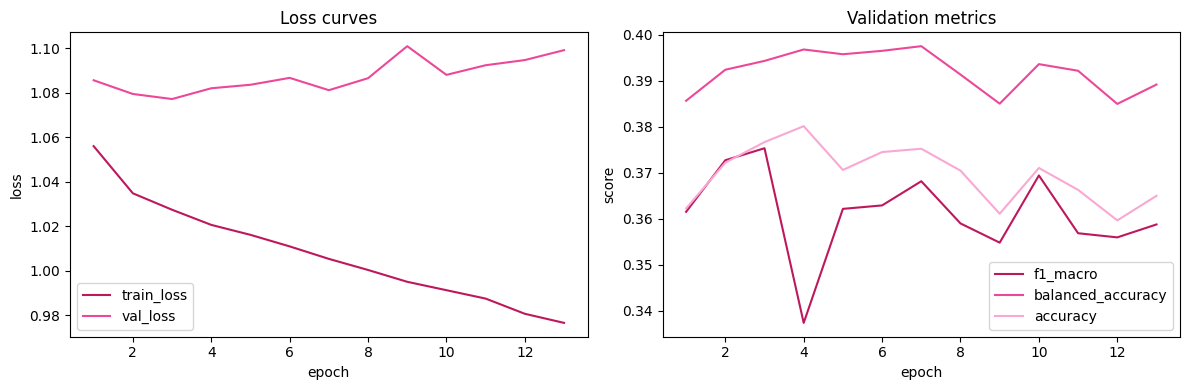

,epoch,train_loss,val_loss,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,lr
2,3,1.027413,1.077234,0.376676,0.394321,0.375342,0.419635,0.394321,0.001000


In [67]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='train_loss', color='#be185d')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val_loss', color='#ec4899')
plt.title('Loss curves')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['f1_macro'], label='f1_macro', color='#be185d')
plt.plot(history_df['epoch'], history_df['balanced_accuracy'], label='balanced_accuracy', color='#ec4899')
plt.plot(history_df['epoch'], history_df['accuracy'], label='accuracy', color='#f9a8d4')
plt.title('Validation metrics')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend()

plt.tight_layout()
plt.show()

best_epoch = int(fit_summary['best_epoch'])
best_row = history_df.loc[history_df['epoch'] == best_epoch].copy()
styler.style_me(best_row, title='Best epoch metrics')


## Shared helpers for Optuna and Top-3


In [ ]:
def build_optimizer(name: str, model: nn.Module, lr: float, weight_decay: float):
    name = str(name).lower()
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(f'Unsupported optimizer: {name}')


def get_scaler(scaler_type: str):
    scaler_type = str(scaler_type).lower()
    if scaler_type == 'standard':
        return StandardScaler()
    if scaler_type == 'robust':
        return RobustScaler()
    raise ValueError(f'Unsupported scaler_type: {scaler_type}')


def compute_class_weights(y: np.ndarray, num_classes: int) -> torch.Tensor:
    counts = np.bincount(y, minlength=num_classes)
    weights = len(y) / (num_classes * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32)


@torch.no_grad()
def evaluate_loader(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_batches = 0
    all_preds = []
    all_targets = []
    all_probs = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

        running_loss += float(loss.item())
        n_batches += 1

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    y_prob = np.concatenate(all_probs)

    metrics = {
        'loss': running_loss / max(1, n_batches),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
    }
    return metrics, y_prob, y_pred, y_true


def parse_top3_row(row: pd.Series) -> dict:
    n_layers = int(row['n_layers'])
    hidden_dims = [int(row[f'hidden_dim_{i}']) for i in range(1, n_layers + 1)]
    return {
        'n_layers': n_layers,
        'hidden_dims': hidden_dims,
        'dropout': float(row['dropout']),
        'activation': str(row['activation']),
        'use_batchnorm': bool(row['use_batchnorm']),
        'optimizer': str(row['optimizer']),
        'lr': float(row['lr']),
        'weight_decay': float(row['weight_decay']),
        'batch_size': int(row['batch_size']),
        'scaler_type': str(row['scaler_type']),
        'clip_grad_norm': float(row['clip_grad_norm']),
    }

In [69]:
train_val_df = pd.concat([train_selected, val_selected], axis=0).sort_values('timestamp').reset_index(drop=True)
X_all = train_val_df[selected_features].to_numpy(dtype=np.float32)
y_all = train_val_df['target'].to_numpy(dtype=np.int64)

## 07 - Optuna 5-fold CV

### 1. Optuna config


In [70]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_SPLITS = 5
N_TRIALS = 30
EPOCHS_PER_FOLD = 20
EARLY_STOPPING_PATIENCE = 5

STUDY_NAME = 'eth_mlp_optimization'
STORAGE_URL = f"sqlite:///{os.path.abspath(LOGS_PATH + 'optuna/optuna.db').replace('\\', '/')}"
DIRECTION = 'maximize'

PRUNER = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)

### 2. Hyperparameter search space


In [ ]:
def suggest_params(trial: optuna.Trial) -> dict:
    n_layers = trial.suggest_int('n_layers', 2, 5)
    hidden_dims = [trial.suggest_int(f'hidden_dim_{i+1}', 32, 512, step=32) for i in range(n_layers)]

    return {
        'hidden_dims': hidden_dims,
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'activation': trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'gelu']),
        'use_batchnorm': trial.suggest_categorical('use_batchnorm', [True, False]),
        'optimizer': trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 1e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        'scaler_type': trial.suggest_categorical('scaler_type', ['standard', 'robust']),
        'clip_grad_norm': trial.suggest_float('clip_grad_norm', 0.5, 5.0),
    }

### 3. Objective with 5-fold TimeSeriesSplit


In [ ]:
def objective(trial: optuna.Trial) -> float:
    params = suggest_params(trial)

    # Required by task: do not randomize fold splitting in objective.
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_scores = []

    trial_log_dir = LOGS_PATH + f'tensorboard/optuna/trial_{trial.number}_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
    writer = SummaryWriter(log_dir=trial_log_dir)

    try:
        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_all), start=1):
            X_train_fold, y_train_fold = X_all[train_idx], y_all[train_idx]
            X_val_fold, y_val_fold = X_all[val_idx], y_all[val_idx]

            scaler = get_scaler(params['scaler_type'])
            X_train_scaled = scaler.fit_transform(X_train_fold).astype(np.float32)
            X_val_scaled = scaler.transform(X_val_fold).astype(np.float32)

            train_loader = DataLoader(
                TabularDataset(X_train_scaled, y_train_fold),
                batch_size=params['batch_size'],
                shuffle=True,
                num_workers=0,
            )
            val_loader = DataLoader(
                TabularDataset(X_val_scaled, y_val_fold),
                batch_size=params['batch_size'],
                shuffle=False,
                num_workers=0,
            )

            model = MLPClassifier(
                input_dim=X_train_scaled.shape[1],
                hidden_dims=params['hidden_dims'],
                num_classes=len(np.unique(y_all)),
                activation=params['activation'],
                dropout=params['dropout'],
                use_batchnorm=params['use_batchnorm'],
            ).to(DEVICE)

            class_weights = compute_class_weights(y_train_fold, num_classes=len(np.unique(y_all))).to(DEVICE)
            criterion = nn.CrossEntropyLoss(weight=class_weights)
            optimizer = build_optimizer(params['optimizer'], model, params['lr'], params['weight_decay'])

            best_fold_f1 = -np.inf
            bad_epochs = 0

            for epoch in range(1, EPOCHS_PER_FOLD + 1):
                train_metrics = train_one_epoch(
                    model=model,
                    dataloader=train_loader,
                    optimizer=optimizer,
                    criterion=criterion,
                    device=DEVICE,
                    clip_grad_norm=params['clip_grad_norm'],
                )
                val_metrics = validate_one_epoch(
                    model=model,
                    dataloader=val_loader,
                    criterion=criterion,
                    device=DEVICE,
                )

                writer.add_scalar(f'trial_{trial.number}/fold_{fold_idx}/train_loss', train_metrics['train_loss'], epoch)
                writer.add_scalar(f'trial_{trial.number}/fold_{fold_idx}/val_loss', val_metrics['val_loss'], epoch)
                writer.add_scalar(f'trial_{trial.number}/fold_{fold_idx}/f1_macro', val_metrics['f1_macro'], epoch)

                if val_metrics['f1_macro'] > best_fold_f1:
                    best_fold_f1 = val_metrics['f1_macro']
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= EARLY_STOPPING_PATIENCE:
                        break

            fold_scores.append(float(best_fold_f1))

            mean_so_far = float(np.mean(fold_scores))
            trial.report(mean_so_far, step=fold_idx)
            writer.add_scalar(f'trial_{trial.number}/mean_f1_so_far', mean_so_far, fold_idx)

            if trial.should_prune():
                raise optuna.TrialPruned()

        final_score = float(np.mean(fold_scores))
        writer.add_scalar(f'trial_{trial.number}/final_mean_f1', final_score, 0)
        return final_score

    finally:
        writer.close()

### 4. Run optimization


In [ ]:
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_URL,
    direction=DIRECTION,
    load_if_exists=True,
    pruner=PRUNER,
)

study.optimize(objective, n_trials=N_TRIALS)

styler.show_line(STUDY_NAME, title='Study name')
styler.show_line(STORAGE_URL, title='Storage')
styler.show_line(study.best_trial.number, title='Best trial number')
styler.show_line(study.best_value, title='Best mean CV f1_macro')
styler.style_me(pd.DataFrame([study.best_params]), title='Best params')

[I 2026-05-10 22:59:07,663] Using an existing study with name 'eth_mlp_optimization' instead of creating a new one.
[I 2026-05-10 23:02:26,968] Trial 95 pruned. 
[I 2026-05-10 23:04:03,332] Trial 96 pruned. 
[I 2026-05-10 23:05:00,962] Trial 97 pruned. 
[I 2026-05-10 23:06:41,534] Trial 98 pruned. 
[I 2026-05-10 23:07:10,035] Trial 99 pruned. 
[I 2026-05-10 23:08:23,236] Trial 100 pruned. 
[I 2026-05-10 23:09:25,075] Trial 101 pruned. 
[I 2026-05-10 23:12:41,100] Trial 102 finished with value: 0.39676713418806986 and parameters: {'n_layers': 2, 'hidden_dim_1': 320, 'hidden_dim_2': 480, 'dropout': 0.18284938902361939, 'activation': 'leaky_relu', 'use_batchnorm': False, 'optimizer': 'adam', 'lr': 0.0007168454034031972, 'weight_decay': 0.0002696876595558543, 'batch_size': 32, 'scaler_type': 'standard', 'clip_grad_norm': 2.994243831179836}. Best is trial 74 with value: 0.39750490758156753.
[I 2026-05-10 23:13:55,417] Trial 103 pruned. 
[I 2026-05-10 23:14:41,477] Trial 104 pruned. 
[I 2026

,n_layers,hidden_dim_1,hidden_dim_2,dropout,activation,use_batchnorm,optimizer,lr,weight_decay,batch_size,scaler_type,clip_grad_norm
0,2,320,480,0.299228,leaky_relu,False,adam,0.001068,0.000125,32,standard,2.315010


### 5. Save summary and top-3 trials


In [74]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params'))
trials_df.to_csv(REPORTS_PATH + 'optuna_trials.csv', index=False)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
completed_sorted = sorted(completed, key=lambda t: t.value, reverse=True)
top3 = completed_sorted[:3]

top3_rows = []
for rank, t in enumerate(top3, start=1):
    top3_rows.append({'rank': rank, 'trial_number': t.number, 'value': float(t.value), **t.params})

top3_df = pd.DataFrame(top3_rows)
top3_df.to_csv(REPORTS_PATH + 'optuna_top3.csv', index=False)

summary = {
    'study_name': STUDY_NAME,
    'best_trial_number': int(study.best_trial.number),
    'best_value': float(study.best_value),
    'best_params': study.best_params,
    'n_trials_total': int(len(study.trials)),
    'n_trials_complete': int(len(completed)),
    'top3': [
        {'rank': i + 1, 'trial_number': int(t.number), 'value': float(t.value), 'params': t.params}
        for i, t in enumerate(top3)
    ],
}

with open(REPORTS_PATH + 'optuna_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

styler.style_me(top3_df, title='Top-3 trials for notebook 08')


,rank,trial_number,value,n_layers,hidden_dim_1,hidden_dim_2,dropout,activation,use_batchnorm,optimizer,lr,weight_decay,batch_size,scaler_type,clip_grad_norm,hidden_dim_3
0,1,120,0.399895,2,320,480,0.299228,leaky_relu,False,adam,0.001068,0.000125,32,standard,2.315010,nan
1,2,111,0.399712,3,320,416,0.234080,leaky_relu,False,adam,0.000662,0.000005,256,standard,4.722953,64.000000
2,3,74,0.397505,2,320,352,0.386025,leaky_relu,False,adam,0.001743,0.000181,32,standard,2.323569,nan


### 6. Optional Optuna visual diagnostics


In [75]:
%pip install plotly
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
fig1 = vis.plot_optimization_history(study)
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.show()

In [77]:
top3_df = pd.read_csv(REPORTS_PATH + 'optuna_top3.csv')
train_val_df = pd.concat([train_selected, val_selected], axis=0).sort_values('timestamp').reset_index(drop=True)
test_df = test_selected.sort_values('timestamp').reset_index(drop=True)


## 08 - Top-3 training, ensembles, uncertainty


### 1. Top-3 x 5-fold training and test prediction

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_SPLITS = 5
EPOCHS = 30
PATIENCE = 8

X_tv = train_val_df[selected_features].to_numpy(dtype=np.float32)
y_tv = train_val_df['target'].to_numpy(dtype=np.int64)
X_test = test_df[selected_features].to_numpy(dtype=np.float32)
y_test = test_df['target'].to_numpy(dtype=np.int64)

run_id = datetime.now().strftime('%Y%m%d_%H%M%S')

all_ensemble_rows = []
metrics_rows = []

for _, top_row in top3_df.sort_values('rank').iterrows():
    rank = int(top_row['rank'])
    trial_number = int(top_row['trial_number'])
    params = parse_top3_row(top_row)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_probabilities = []
    fold_metric_rows = []

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_tv), start=1):
        X_train_fold, y_train_fold = X_tv[train_idx], y_tv[train_idx]
        X_val_fold, y_val_fold = X_tv[val_idx], y_tv[val_idx]

        scaler = get_scaler(params['scaler_type'])
        X_train_scaled = scaler.fit_transform(X_train_fold).astype(np.float32)
        X_val_scaled = scaler.transform(X_val_fold).astype(np.float32)
        X_test_scaled = scaler.transform(X_test).astype(np.float32)

        train_loader = DataLoader(
            TabularDataset(X_train_scaled, y_train_fold),
            batch_size=params['batch_size'],
            shuffle=True,
            drop_last=True,
            num_workers=0,
        )
        val_loader = DataLoader(
            TabularDataset(X_val_scaled, y_val_fold),
            batch_size=params['batch_size'],
            shuffle=False,
            num_workers=0,
        )
        test_loader = DataLoader(
            TabularDataset(X_test_scaled, y_test),
            batch_size=params['batch_size'],
            shuffle=False,
            num_workers=0,
        )

        model = MLPClassifier(
            input_dim=X_train_scaled.shape[1],
            hidden_dims=params['hidden_dims'],
            num_classes=len(np.unique(y_tv)),
            activation=params['activation'],
            dropout=params['dropout'],
            use_batchnorm=params['use_batchnorm'],
        ).to(DEVICE)

        class_weights = compute_class_weights(y_train_fold, num_classes=len(np.unique(y_tv))).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = build_optimizer(params['optimizer'], model, params['lr'], params['weight_decay'])

        best_f1 = -np.inf
        bad_epochs = 0

        tb_dir = LOGS_PATH + f'tensorboard/top3_cv/run_{run_id}_rank{rank}_fold{fold_idx}'
        writer = SummaryWriter(log_dir=tb_dir)

        ckpt_path = CHECKPOINTS_PATH + f'top3_cv/run_{run_id}_rank{rank}_fold{fold_idx}.pt'

        for epoch in range(1, EPOCHS + 1):
            train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, params['clip_grad_norm'])
            train_loss = train_metrics['train_loss']
            val_metrics, _, _, _ = evaluate_loader(model, val_loader, criterion, DEVICE)

            writer.add_scalar('loss/train', train_loss, epoch)
            writer.add_scalar('loss/val', val_metrics['loss'], epoch)
            writer.add_scalar('metrics/f1_macro', val_metrics['f1_macro'], epoch)

            if val_metrics['f1_macro'] > best_f1:
                best_f1 = val_metrics['f1_macro']
                bad_epochs = 0
                torch.save(
                    {
                        'model_state_dict': model.state_dict(),
                        'params': params,
                        'rank': rank,
                        'trial_number': trial_number,
                        'fold': fold_idx,
                        'best_val_f1': best_f1,
                    },
                    ckpt_path,
                )
            else:
                bad_epochs += 1
                if bad_epochs >= PATIENCE:
                    break

        writer.close()

        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])

        val_metrics, _, _, _ = evaluate_loader(model, val_loader, criterion, DEVICE)
        test_metrics, test_probs, test_preds, test_true = evaluate_loader(model, test_loader, criterion, DEVICE)

        fold_probabilities.append(test_probs)

        fold_metric_rows.append({
            'rank': rank,
            'trial_number': trial_number,
            'fold': fold_idx,
            'best_val_f1': float(ckpt['best_val_f1']),
            'test_f1_macro': float(test_metrics['f1_macro']),
            'test_balanced_accuracy': float(test_metrics['balanced_accuracy']),
            'test_accuracy': float(test_metrics['accuracy']),
        })

        model_pred_df = pd.DataFrame({
            'timestamp': test_df['timestamp'].astype(str),
            'y_true': test_true,
            'y_pred': test_preds,
            'prob_sell': test_probs[:, 0],
            'prob_hold': test_probs[:, 1],
            'prob_buy': test_probs[:, 2],
        })
        model_pred_path = REPORTS_PATH + f'predictions/run_{run_id}_rank{rank}_fold{fold_idx}_test_predictions.csv'
        model_pred_df.to_csv(model_pred_path, index=False)

    stacked = np.stack(fold_probabilities, axis=0)  # [5, n_test, n_classes]
    ensemble_probs = stacked.mean(axis=0)
    ensemble_preds = np.argmax(ensemble_probs, axis=1)

    ensemble_metrics = {
        'rank': rank,
        'trial_number': trial_number,
        'cv_score_from_optuna': float(top_row['value']),
        'test_f1_macro': float(f1_score(y_test, ensemble_preds, average='macro', zero_division=0)),
        'test_balanced_accuracy': float(balanced_accuracy_score(y_test, ensemble_preds)),
        'test_accuracy': float(accuracy_score(y_test, ensemble_preds)),
        'test_precision_macro': float(precision_score(y_test, ensemble_preds, average='macro', zero_division=0)),
        'test_recall_macro': float(recall_score(y_test, ensemble_preds, average='macro', zero_division=0)),
    }
    metrics_rows.append(ensemble_metrics)

    # Uncertainty
    prob_std = stacked.std(axis=0)
    mean_prob_std = prob_std.mean(axis=1)
    ent = entropy(ensemble_probs.T)
    sorted_probs = np.sort(ensemble_probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    ensemble_df = pd.DataFrame({
        'timestamp': test_df['timestamp'].astype(str),
        'y_true': y_test,
        'y_pred': ensemble_preds,
        'prob_sell': ensemble_probs[:, 0],
        'prob_hold': ensemble_probs[:, 1],
        'prob_buy': ensemble_probs[:, 2],
        'uncertainty_entropy': ent,
        'uncertainty_margin': margin,
        'uncertainty_mean_prob_std': mean_prob_std,
    })

    ensemble_path = REPORTS_PATH + f'predictions/run_{run_id}_rank{rank}_ensemble_test_predictions.csv'
    ensemble_df.to_csv(ensemble_path, index=False)

    all_ensemble_rows.extend(fold_metric_rows)

### 2. Save final reports

In [79]:
metrics_df = pd.DataFrame(metrics_rows).sort_values('rank')
fold_metrics_df = pd.DataFrame(all_ensemble_rows).sort_values(['rank', 'fold'])

metrics_path = REPORTS_PATH + f'top3_ensemble_metrics_{run_id}.csv'
fold_metrics_path = REPORTS_PATH + f'top3_fold_metrics_{run_id}.csv'
summary_path = REPORTS_PATH + f'top3_ensemble_summary_{run_id}.json'
latest_metrics_alias = REPORTS_PATH + 'top3_ensemble_metrics.csv'
latest_summary_alias = REPORTS_PATH + 'top3_ensemble_summary.json'

metrics_df.to_csv(metrics_path, index=False)
metrics_df.to_csv(latest_metrics_alias, index=False)
fold_metrics_df.to_csv(fold_metrics_path, index=False)

summary = {
    'run_id': run_id,
    'n_sets': int(len(metrics_df)),
    'n_folds_per_set': int(N_SPLITS),
    'metrics_file': metrics_path,
    'fold_metrics_file': fold_metrics_path,
    'best_set_by_test_f1': metrics_df.sort_values('test_f1_macro', ascending=False).iloc[0].to_dict() if len(metrics_df) else None,
}
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
with open(latest_summary_alias, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

styler.style_me(metrics_df, title='Top-3 ensemble metrics on test')
styler.style_me(fold_metrics_df, title='Fold-level metrics (5 models per set)')
styler.show_line(metrics_path, title='Saved metrics file')
styler.show_line(summary_path, title='Saved summary file')


,rank,trial_number,cv_score_from_optuna,test_f1_macro,test_balanced_accuracy,test_accuracy,test_precision_macro,test_recall_macro
0,1,120,0.399895,0.375114,0.394186,0.394293,0.408763,0.394186
1,2,111,0.399712,0.371213,0.394430,0.407119,0.399820,0.394430
2,3,74,0.397505,0.379828,0.390483,0.400346,0.397760,0.390483


,rank,trial_number,fold,best_val_f1,test_f1_macro,test_balanced_accuracy,test_accuracy
0,1,120,1,0.368135,0.366591,0.379120,0.414613
1,1,120,2,0.397245,0.377660,0.382575,0.409713
2,1,120,3,0.412046,0.360846,0.391534,0.366479
3,1,120,4,0.407139,0.331787,0.373503,0.336216
4,1,120,5,0.366596,0.324455,0.362611,0.329298
5,2,111,1,0.371867,0.343335,0.355300,0.398761
6,2,111,2,0.396854,0.379375,0.399519,0.409281
7,2,111,3,0.404689,0.356287,0.378577,0.374982
8,2,111,4,0.414599,0.331215,0.367639,0.332901
9,2,111,5,0.384622,0.371075,0.401542,0.376711


### 3. Quick uncertainty summary

In [ ]:
summary_rows = []
for rank in sorted(metrics_df['rank'].unique()):
    p = REPORTS_PATH + f'predictions/run_{run_id}_rank{rank}_ensemble_test_predictions.csv'
    if os.path.exists(p):
        df = pd.read_csv(p)
        summary_rows.append({
            'rank': rank,
            'mean_entropy': float(df['uncertainty_entropy'].mean()),
            'mean_margin': float(df['uncertainty_margin'].mean()),
            'mean_prob_std': float(df['uncertainty_mean_prob_std'].mean()),
        })

uncertainty_summary_df = pd.DataFrame(summary_rows).sort_values('rank')
styler.style_me(uncertainty_summary_df, title='Uncertainty summary per top-set')

,rank,mean_entropy,mean_margin,mean_prob_std
0,1,1.064241,0.103571,0.071483
1,2,1.060401,0.124220,0.090606
2,3,1.072837,0.084441,0.052985


## 09 - Statistical tests and final report


In [ ]:
metrics_df = pd.read_csv(REPORTS_PATH + 'top3_ensemble_metrics.csv').sort_values('rank').reset_index(drop=True)
with open(REPORTS_PATH + 'top3_ensemble_summary.json', 'r', encoding='utf-8') as f:
    top3_summary = json.load(f)
run_id = top3_summary['run_id']

### 1. Load ensemble predictions (3 sets) and align timestamps


In [ ]:
def load_ensemble_predictions(rank: int, run_id: str) -> pd.DataFrame:
    path = REPORTS_PATH + f'predictions/run_{run_id}_rank{rank}_ensemble_test_predictions.csv'
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing prediction file for rank {rank}: {path}')
    df = pd.read_csv(path)
    required = ['timestamp', 'y_true', 'y_pred', 'prob_sell', 'prob_hold', 'prob_buy']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'File {path} missing columns: {missing}')
    return df

preds = {}
for rank in [1, 2, 3]:
    preds[rank] = load_ensemble_predictions(rank, run_id)

# Align by timestamp to guarantee same sample order.
base_ts = preds[1]['timestamp'].astype(str)
for rank in [2, 3]:
    merged = pd.merge(
        preds[1][['timestamp']],
        preds[rank],
        on='timestamp',
        how='left',
    )
    assert merged['y_pred'].notna().all(), f'Rank {rank} missing timestamps after alignment'
    preds[rank] = merged

alignment_report = pd.DataFrame({
    'rank': [1, 2, 3],
    'rows': [len(preds[1]), len(preds[2]), len(preds[3])],
    'unique_timestamps': [preds[1]['timestamp'].nunique(), preds[2]['timestamp'].nunique(), preds[3]['timestamp'].nunique()],
})
styler.style_me(alignment_report, title='Prediction alignment report')

,rank,rows,unique_timestamps
0,1,6939,6939
1,2,6939,6939
2,3,6939,6939


### 2. Helper functions: bootstrap, McNemar, Holm correction


In [ ]:
def bootstrap_metric_difference(
    y_true: np.ndarray,
    y_pred_a: np.ndarray,
    y_pred_b: np.ndarray,
    metric_fn,
    n_bootstrap: int = 2000,
    random_state: int = 42,
):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        score_a = metric_fn(y_true[idx], y_pred_a[idx])
        score_b = metric_fn(y_true[idx], y_pred_b[idx])
        diffs.append(score_a - score_b)

    diffs = np.array(diffs)
    return {
        'mean_diff': float(np.mean(diffs)),
        'ci_lower_95': float(np.quantile(diffs, 0.025)),
        'ci_upper_95': float(np.quantile(diffs, 0.975)),
    }


def mcnemar_test(y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray):
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)

    n01 = int(np.sum((correct_a == 1) & (correct_b == 0)))  # A correct, B wrong
    n10 = int(np.sum((correct_a == 0) & (correct_b == 1)))  # A wrong, B correct

    # If n01+n10 == 0, predictions are identical wrt correctness.
    if n01 + n10 == 0:
        return {'n01': n01, 'n10': n10, 'chi2': 0.0, 'p_value': 1.0}

    # Continuity-corrected McNemar statistic.
    chi2_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p_value = float(1 - chi2.cdf(chi2_stat, df=1))
    return {'n01': n01, 'n10': n10, 'chi2': float(chi2_stat), 'p_value': p_value}


def holm_correction(pvals: list[float]) -> list[float]:
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m, dtype=float)

    running_max = 0.0
    for i, idx in enumerate(order):
        adj = (m - i) * pvals[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(1.0, running_max)

    return adjusted.tolist()

### 3. Pairwise statistical comparison between 3 ensembles


In [84]:
y_true = preds[1]['y_true'].to_numpy(dtype=np.int64)

pairs = [(1, 2), (1, 3), (2, 3)]
rows = []
mcnemar_pvals = []
mcnemar_rows_cache = []

for a, b in pairs:
    y_pred_a = preds[a]['y_pred'].to_numpy(dtype=np.int64)
    y_pred_b = preds[b]['y_pred'].to_numpy(dtype=np.int64)

    bs_f1 = bootstrap_metric_difference(
        y_true=y_true,
        y_pred_a=y_pred_a,
        y_pred_b=y_pred_b,
        metric_fn=lambda yt, yp: float(f1_score(yt, yp, average='macro', zero_division=0)),
    )
    bs_bal = bootstrap_metric_difference(
        y_true=y_true,
        y_pred_a=y_pred_a,
        y_pred_b=y_pred_b,
        metric_fn=lambda yt, yp: float(balanced_accuracy_score(yt, yp)),
    )
    bs_acc = bootstrap_metric_difference(
        y_true=y_true,
        y_pred_a=y_pred_a,
        y_pred_b=y_pred_b,
        metric_fn=lambda yt, yp: float(accuracy_score(yt, yp)),
    )

    mc = mcnemar_test(y_true=y_true, y_pred_a=y_pred_a, y_pred_b=y_pred_b)
    mcnemar_pvals.append(mc['p_value'])
    mcnemar_rows_cache.append((a, b, mc))

    rows.append({
        'pair': f'rank{a}_vs_rank{b}',
        'f1_mean_diff': bs_f1['mean_diff'],
        'f1_ci_low': bs_f1['ci_lower_95'],
        'f1_ci_high': bs_f1['ci_upper_95'],
        'balacc_mean_diff': bs_bal['mean_diff'],
        'balacc_ci_low': bs_bal['ci_lower_95'],
        'balacc_ci_high': bs_bal['ci_upper_95'],
        'acc_mean_diff': bs_acc['mean_diff'],
        'acc_ci_low': bs_acc['ci_lower_95'],
        'acc_ci_high': bs_acc['ci_upper_95'],
        'mcnemar_n01': mc['n01'],
        'mcnemar_n10': mc['n10'],
        'mcnemar_chi2': mc['chi2'],
        'mcnemar_p': mc['p_value'],
    })

stat_df = pd.DataFrame(rows)
styler.style_me(stat_df)


,pair,f1_mean_diff,f1_ci_low,f1_ci_high,balacc_mean_diff,balacc_ci_low,balacc_ci_high,acc_mean_diff,acc_ci_low,acc_ci_high,mcnemar_n01,mcnemar_n10,mcnemar_chi2,mcnemar_p
0,rank1_vs_rank2,0.003725,-0.005755,0.013585,-0.000385,-0.009892,0.009573,-0.012989,-0.022197,-0.004035,477,566,7.424736,0.006433
1,rank1_vs_rank3,-0.004806,-0.014798,0.005081,0.003618,-0.006791,0.013908,-0.006148,-0.015708,0.002893,521,563,1.550738,0.213027
2,rank2_vs_rank3,-0.008531,-0.019407,0.001948,0.004003,-0.007041,0.014834,0.006842,-0.003603,0.016721,670,623,1.636504,0.200806


### 4. Multiple-comparison correction (Holm)


In [ ]:
adj = holm_correction(mcnemar_pvals)

for i, p_adj in enumerate(adj):
    stat_df.loc[i, 'mcnemar_p_holm'] = p_adj
    stat_df.loc[i, 'mcnemar_significant_0_05'] = bool(p_adj < 0.05)

# For bootstrap CI: significance if CI does not include 0.
stat_df['f1_diff_significant_by_ci'] = ~((stat_df['f1_ci_low'] <= 0) & (stat_df['f1_ci_high'] >= 0))
stat_df['balacc_diff_significant_by_ci'] = ~((stat_df['balacc_ci_low'] <= 0) & (stat_df['balacc_ci_high'] >= 0))
stat_df['acc_diff_significant_by_ci'] = ~((stat_df['acc_ci_low'] <= 0) & (stat_df['acc_ci_high'] >= 0))

styler.style_me(stat_df, title='Pairwise statistical tests (with Holm correction)')


,pair,f1_mean_diff,f1_ci_low,f1_ci_high,balacc_mean_diff,balacc_ci_low,balacc_ci_high,acc_mean_diff,acc_ci_low,acc_ci_high,mcnemar_n01,mcnemar_n10,mcnemar_chi2,mcnemar_p,mcnemar_p_holm,mcnemar_significant_0_05,f1_diff_significant_by_ci,balacc_diff_significant_by_ci,acc_diff_significant_by_ci
0,rank1_vs_rank2,0.003725,-0.005755,0.013585,-0.000385,-0.009892,0.009573,-0.012989,-0.022197,-0.004035,477,566,7.424736,0.006433,0.019300,True,False,False,True
1,rank1_vs_rank3,-0.004806,-0.014798,0.005081,0.003618,-0.006791,0.013908,-0.006148,-0.015708,0.002893,521,563,1.550738,0.213027,0.401612,False,False,False,False
2,rank2_vs_rank3,-0.008531,-0.019407,0.001948,0.004003,-0.007041,0.014834,0.006842,-0.003603,0.016721,670,623,1.636504,0.200806,0.401612,False,False,False,False


### 5. Final ranking summary


In [ ]:
rank_metrics = metrics_df[['rank', 'trial_number', 'test_f1_macro', 'test_balanced_accuracy', 'test_accuracy']].copy()
rank_metrics = rank_metrics.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
rank_metrics['order_by_test_f1'] = np.arange(1, len(rank_metrics) + 1)

styler.style_me(rank_metrics, title='Ensemble ranking by test f1_macro')

,rank,trial_number,test_f1_macro,test_balanced_accuracy,test_accuracy,order_by_test_f1
0,3,74,0.379828,0.390483,0.400346,1
1,1,120,0.375114,0.394186,0.394293,2
2,2,111,0.371213,0.394430,0.407119,3


### 6. Save statistical report artifacts


In [ ]:
STAT_CSV = REPORTS_PATH + 'stat_tests_summary.csv'
STAT_JSON = REPORTS_PATH + 'stat_tests_summary.json'
RANKING_CSV = REPORTS_PATH + 'final_ensemble_ranking.csv'

stat_df.to_csv(STAT_CSV, index=False)
rank_metrics.to_csv(RANKING_CSV, index=False)

payload = {
    'run_id': run_id,
    'pairs_tested': stat_df.to_dict(orient='records'),
    'ranking_by_test_f1': rank_metrics.to_dict(orient='records'),
    'notes': {
        'bootstrap_metric_diff': 'Difference defined as metric(rankA) - metric(rankB).',
        'mcnemar': 'Continuity-corrected McNemar test on correctness disagreement table.',
        'multiple_comparison_correction': 'Holm correction over 3 pairwise McNemar p-values.',
    },
}
with open(STAT_JSON, 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

styler.show_line(STAT_CSV, title='Saved statistical summary CSV')
styler.show_line(STAT_JSON, title='Saved statistical summary JSON')
styler.show_line(RANKING_CSV, title='Saved final ranking CSV')